# Narrative Miners: Uncover the Stories That Drive Markets

## Automated Analysis of Market Narratives Across Multiple Document Sources

## Why It Matters

Understanding how market narratives emerge and evolve across different information sources is crucial for investment decision-making, but manually tracking narrative development across scattered news coverage, earnings calls, and regulatory filings is time consuming. Investment decisions need systematic analysis of narrative progression to identify emerging trends and timing patterns.

## What It Does

The `NarrativeMiner` class in the bigdata-research-tools package systematically tracks narrative evolution across multiple document types using unstructured data from news, transcripts, and filings. Built for analysts, portfolio managers, and investment professionals, it transforms scattered narrative signals into quantified trend intelligence and identifies timing patterns across different information sources.

## How It Works

The `NarrativeMiner` combines **multi-source content retrieval**, **temporal narrative tracking**, and **cross-source comparative analysis** to deliver:

- **Cross-document narrative mapping** across news media, earnings calls, and SEC filings
- **Temporal evolution tracking** showing how narratives develop and change over time across sources
- **Intensity measurement** quantifying narrative prevalence and significance across document types

## A Real-World Use Case

This cookbook demonstrates the complete workflow through analyzing "AI Bubble Concerns" narrative as it emerges and evolves across news, earnings calls, and regulatory filings, highlighting the difference between public discourse and corporate communications.

## Setup and Imports

## Async Compatibility Setup

**Run this cell first** - Required for Google Colab, Jupyter Notebooks, and VS Code with Jupyter extension:

### Why is this needed?

Interactive environments (Colab, Jupyter) already have an asyncio event loop running. When bigdata-research-tools makes async API calls (like to OpenAI), you'll get this error without nest_asyncio:

```
RuntimeError: asyncio.run() cannot be called from a running event loop
```

The `nest_asyncio.apply()` command patches this to allow nested event loops.

💡 **Tip**: If you're unsure which environment you're in, just run the cell below - it won't hurt in any environment!

In [1]:
import datetime
start = datetime.datetime.now()

try:
    import asyncio
    asyncio.get_running_loop()
    import nest_asyncio; nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except (RuntimeError, ImportError):
    print("✅ nest_asyncio not needed or not available")

✅ nest_asyncio applied


## Environment Setup

The following cell configures the necessary path for the analysis

In [2]:
import os
import sys

current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)
print(f"✅ Local environment setup complete")

✅ Local environment setup complete


## Import Required Libraries

Import the core libraries needed for narrative mining analysis, including the custom visualization and analysis tools.

In [3]:
from IPython.display import display, HTML, IFrame
import pandas as pd
from pandas import merge

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings

from src.tool import (
    load_results, 
    extract_narrative_insights,
    create_source_summary,
    display_sample_data,
    visualize_cross_source_narratives, 
    visualize_news_narrative_breakdown
)

from bigdata_research_tools.workflows.narrative_miner import NarrativeMiner
from bigdata_research_tools.excel import ExcelManager
from bigdata_client import Bigdata
from bigdata_client.daterange import RollingDateRange
from bigdata_client.models.sources import Source
from bigdata_client.models.search import DocumentType

## Optional: Plotly Display Configuration

For better visualization rendering, you can also set the Plotly renderer:

In [4]:
import plotly
import plotly.graph_objects as go
import plotly.io as pio

# Try to detect the environment and set appropriate renderer
try:
    # Check if we're in JupyterLab
    import os
    if 'JUPYTERHUB_SERVICE_PREFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
        print("✅ Plotly configured for JupyterLab")
    else:
        # Default for VS Code, Jupyter Notebook, etc.
        pio.renderers.default = 'plotly_mimetype+notebook'
        print("✅ Plotly configured for Jupyter/VS Code")
except:
    # Fallback to a more universal renderer
    pio.renderers.default = 'notebook'
    print("✅ Plotly configured with fallback renderer")



✅ Plotly configured for Jupyter/VS Code


/opt/anaconda/envs/pricing_power/lib/python3.11/site-packages/kaleido/__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




## Define Output Paths

We define the output paths for our narrative mining results.

In [5]:
# Define output file paths for our results
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

news_results_path = f"{output_dir}/ai_bubble_news.xlsx"
transcripts_results_path = f"{output_dir}/ai_bubble_transcripts.xlsx"
filings_results_path = f"{output_dir}/ai_bubble_filings.xlsx"
visualization_path = f"{output_dir}/ai_bubble_narratives.html"

## Load Credentials

In [6]:
from dotenv import load_dotenv
from pathlib import Path

script_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
load_dotenv(script_dir / '.env')

BIGDATA_USERNAME = os.getenv('BIGDATA_USERNAME')
BIGDATA_PASSWORD = os.getenv('BIGDATA_PASSWORD')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

if not all([BIGDATA_USERNAME, BIGDATA_PASSWORD, OPENAI_API_KEY]):
    print("❌ Missing required environment variables")
    raise ValueError("Missing required environment variables. Check your .env file.")
else:
    print("✅ Credentials loaded from .env file")

✅ Credentials loaded from .env file


## Connecting to Bigdata

Create a Bigdata object with your credentials.

In [7]:
bigdata = Bigdata(BIGDATA_USERNAME, BIGDATA_PASSWORD)

## Defining the Narrative Analysis Parameters

### Fixed Parameters
- **AI Bubble Narratives** (`main_narratives`): Specific narrative sentences related to AI bubble concerns
- **Common Parameters** (`common_params`): Shared configuration across all narrative miners
- **Model Selection** (`llm_model`): The LLM model used for narrative labeling and analysis
- **Time Period** (`start_date` and `end_date`): The date range over which to run the analysis
- **Rerank Threshold** (`rerank_threshold`): Cross-encoder threshold for result relevance filtering
- **Document Limits** (`document_limit`): Maximum number of documents to retrieve per query
- **Search Frequency** (`freq`): Frequency of date ranges for search operations

In [ ]:
# AI Bubble Narratives
main_narratives = ['A proposed tax impacting companies employing H-1B visa holders.',
 'New tax may hinder recruitment of skilled H-1B visa workers.',
 'Higher costs may deter companies from hiring H-1B visa candidates.',
 'Companies may prioritize domestic candidates over H-1B visa applicants.',
 'Tax may exacerbate shortages in specialized skills from H-1B visa workers.',
 'Companies may alter recruitment strategies to minimize H-1B visa reliance.',
 'Tax increases operational costs for companies employing H-1B visa workers.',
 'Companies may need to allocate budgets for new H-1B visa taxes.',
 'Increased costs from H-1B visa taxes may reduce profit margins.',
 'Companies may reassess the financial viability of hiring H-1B visa workers.',
 'Companies may restructure operations to offset H-1B visa tax costs.',
 "Tax may affect companies' competitiveness in the global market.",
 'Higher costs may weaken competitiveness against international firms not facing H-1B visa taxes.',
 'Companies may need to adjust pricing due to increased H-1B visa costs.',
 'Competitors may attract H-1B visa talent by offering better conditions.',
 'Companies may need to rethink global strategies to attract H-1B visa talent.',
 'Tax influences long-term workforce planning regarding H-1B visa employees.',
 'Companies may struggle to develop a robust talent pipeline for H-1B visa roles.',
 'Tax may influence decisions to onshore or offshore roles typically filled by H-1B visa workers.',
 'Tax may limit diversity by reducing H-1B visa hiring.',
 'Companies may need to reassess skill requirements due to H-1B visa tax.',
 'Tax may impact innovation driven by H-1B visa talent.',
 'Reduced H-1B visa hiring may limit research and development initiatives.',
 'Tax may disrupt the flow of innovative ideas from H-1B visa workers.',
 'Tax may hinder collaboration with international H-1B visa talent.',
 'Reduced H-1B visa workforce may slow technological advancements.']
 
# LLM Specification
llm_model = "openai::gpt-4o-mini"


# Specify Time Range
start_date = "2025-09-19"
end_date = "2025-09-24"

# Rerank Threshold
rerank_threshold = 0.7

# Search Frequency
freq = 'D'

# Fiscal Year
fiscal_year = 2025

# Document Limits
document_limit = 100

# Commen Params
common_params = {
    "narrative_sentences": main_narratives,
    "llm_model": llm_model,
    "start_date": start_date,
    "end_date": end_date,
    "rerank_threshold": rerank_threshold}

## Configure the Narrative Miners

Create narrative miners for each document type. In this example, we select MT Newswires as the news source.

In [9]:
# Common Params
common_params = {
    "narrative_sentences": main_narratives,
    "llm_model": llm_model,
    "start_date": start_date,
    "end_date": end_date,
    "rerank_threshold": rerank_threshold}
    

# Create the specialized miners for each document type
news_miner = NarrativeMiner(
    document_type=DocumentType.NEWS,
    fiscal_year=None,
    **common_params
)

## Run Narrative Mining

Execute the narrative mining processes for news:

In [10]:
# Mine news narratives
print("Mining news narratives...")
try:
    news_results = news_miner.mine_narratives(
        document_limit=document_limit,
        freq=freq,
        export_path=news_results_path
    )
    print("✅ News mining completed successfully!")
except Exception as e:
    print(f"Warning during news mining: {e}")

Mining news narratives...


Querying OpenAI...: 100%|██████████| 7078/7078 [05:34<00:00, 21.13it/s]


✅ News mining completed successfully!


# First Labeling

In [43]:
df.head()

,Time Period,Date,Document ID,Sentence ID,Headline,Chunk Text,Motivation,Label,Entity,Country Code,Entity Type,Theme Matching Label,Theme Matching Motivation
884,Sep 2025,2025-09-11,171DDC2956F695345A0FD599C7016B90,171DDC2956F695345A0FD599C7016B90-1,Why Indian IT Companies Are Ditching H-1B Work...,Indian IT firms are cutting H-1B visa use amid...,The sentence discusses how Indian IT firms are...,Companies may alter recruitment strategies to ...,Big Tech,None,BUSI,related,The sentence discusses the reduction in H-1B v...
885,Sep 2025,2025-09-11,171DDC2956F695345A0FD599C7016B90,171DDC2956F695345A0FD599C7016B90-1,Why Indian IT Companies Are Ditching H-1B Work...,Indian IT firms are cutting H-1B visa use amid...,The sentence discusses how Indian IT firms are...,Companies may alter recruitment strategies to ...,Work Visa,None,LAWS,related,The sentence discusses the reduction in H-1B v...
886,Sep 2025,2025-09-11,171DDC2956F695345A0FD599C7016B90,171DDC2956F695345A0FD599C7016B90-1,Why Indian IT Companies Are Ditching H-1B Work...,Indian IT firms are cutting H-1B visa use amid...,The sentence discusses how Indian IT firms are...,Companies may alter recruitment strategies to ...,LTIMindtree Ltd. /Old,India,COMP,related,The sentence discusses the reduction in H-1B v...
887,Sep 2025,2025-09-11,171DDC2956F695345A0FD599C7016B90,171DDC2956F695345A0FD599C7016B90-1,Why Indian IT Companies Are Ditching H-1B Work...,Indian IT firms are cutting H-1B visa use amid...,The sentence discusses how Indian IT firms are...,Companies may alter recruitment strategies to ...,Immigration,None,SOCI,related,The sentence discusses the reduction in H-1B v...
888,Sep 2025,2025-09-11,171DDC2956F695345A0FD599C7016B90,171DDC2956F695345A0FD599C7016B90-1,Why Indian IT Companies Are Ditching H-1B Work...,Indian IT firms are cutting H-1B visa use amid...,The sentence discusses how Indian IT firms are...,Companies may alter recruitment strategies to ...,Automation,None,TECH,related,The sentence discusses the reduction in H-1B v...


In [11]:
df = news_results["df_labeled"]
print(len(df))
df_sentence_unique = df.drop_duplicates(subset=["Sentence ID"]).reset_index(drop=True)
print(len(df_sentence_unique))


68451
3342


In [13]:
from src.labeler.narrative_labeler import NarrativeLabeler
labeler = NarrativeLabeler(llm_model=llm_model)


In [14]:
df_sentence_unique_labeled = labeler.get_labels(
    main_theme="Introduction of a high fee on H-1B visas",
    texts=df_sentence_unique["Chunk Text"].tolist(),
    titles=df_sentence_unique["Headline"].tolist(),
    mode="theme_matching",
)

Querying OpenAI...: 100%|██████████| 3342/3342 [02:05<00:00, 26.68it/s]


In [15]:
df_sentence_unique_labeled.rename(columns={"label": "Theme Matching Label", "motivation": "Theme Matching Motivation"}, inplace=True)
df_sentence_unique_labeled_merged = merge(df_sentence_unique, df_sentence_unique_labeled, left_index=True, right_index=True)


In [16]:
# Select columns from df_sentence_unique_labeled_filtered
columns_to_merge = df_sentence_unique_labeled_merged[['Sentence ID', 'Theme Matching Label', 'Theme Matching Motivation']]

# Merge with df on Sentence ID
df_sentences_merged = df.merge(columns_to_merge, on='Sentence ID', how='left')

df_sentences_related = df_sentences_merged[df_sentences_merged["Theme Matching Label"] != "unclear"]


# Creating the DF

In [21]:
df = df_sentences_related.copy()

In [22]:
df_company = df[df["Entity Type"] == "COMP"]


In [23]:
df_DonaldTrump = df[df["Entity"] == "Donald Trump"]

#Top three People Entities
counts = df[df["Entity Type"] == "PEOP"]["Entity"].value_counts()
top_3 = counts[counts.index != "Donald Trump"].head(3).index.tolist()

top_3_dict_entities = {}
for name in top_3:
    top_3_dict_entities[name] = df[df["Entity"] == name]

print(top_3_dict_entities.keys())


dict_keys(['Howard Lutnick', 'Elon Musk', 'Reed Hastings'])


In [42]:
# Filter for United States
df_US = df[df["Country Code"] == "United States"]

# Get top 5 companies from United States
counts = df_US[df_US["Entity Type"] == "COMP"]["Entity"].value_counts()
top_3_companies_US = counts.head(3).index.tolist()

# Create dictionary with dataframes for each top 5 company
top_3_companies_US_dict = {}
for company in top_3_companies_US:
    top_3_companies_US_dict[company] = df_US[df_US["Entity"] == company]

print(top_3_companies_US_dict.keys())

dict_keys(['Amazon.com Inc.', 'Microsoft Corp.', 'Alphabet Inc.'])


In [25]:
# Get value counts for places excluding India and United States
counts = df[df["Entity Type"] == "PLCE"]["Country Code"].value_counts()
top_3_places = counts[~counts.index.isin(["United States", "India"])].head(3).index.tolist()

# Create dictionary with dataframes for each top 3 place using Country Code
top_3_places_dict = {}
for place in top_3_places:
    top_3_places_dict[place] = df[df["Country Code"] == place]

print(top_3_places_dict.keys())

dict_keys(['China', 'Canada', 'United Kingdom'])


In [26]:
# Create dictionary of dictionaries with top 5 companies for each place
top_3_places_companies = {}

for place in top_3_places:
    df_place = top_3_places_dict[place]
    counts = df_place[df_place["Entity Type"] == "COMP"]["Entity"].value_counts()
    top_3_companies = counts.head(3).index.tolist()
    print(top_3_companies)
    companies_dict = {}
    for company in top_3_companies:
        companies_dict[company] = df_place[df_place["Entity"] == company]
    
    top_3_places_companies[place] = companies_dict

print(top_3_places_companies.keys())

['IBM Corp. Pty. Ltd.', 'Dewang', 'Metaview']
['Thomson Reuters Corp.', 'Talent Fund', 'Canadian Broadcasting Corp.']
['The Financial Times Ltd.', 'Crossbridge Capital LLP', 'AJ Bell PLC', 'HSBC Holdings PLC', 'Universities UK']
dict_keys(['China', 'Canada', 'United Kingdom'])


dict_keys(['Infosys Ltd.', 'Wipro Ltd.', 'Tata Consultancy Services Ltd.'])


# LABELING

In [28]:
from src.labeler.screener_labeler import ScreenerSummarizerFlex, ScreenerLabelerFlex

## Trump Position

In [29]:
# Convert Date column to datetime for proper sorting
df_DonaldTrump_refined = df_DonaldTrump.copy()
df_DonaldTrump_refined['Date'] = pd.to_datetime(df_DonaldTrump_refined['Date'])

# Sort by Date (oldest first)
df_DonaldTrump_refined = df_DonaldTrump_refined.sort_values('Date')

# Remove duplicates keeping the first occurrence (oldest)
df_DonaldTrump_refined = df_DonaldTrump_refined.drop_duplicates(subset='Chunk Text', keep='first')

# Reset index
df_DonaldTrump_refined = df_DonaldTrump_refined.reset_index(drop=True)

print(len(df_DonaldTrump_refined))
print(len(df_DonaldTrump))


504
1555


In [ ]:
import importlib
import sys

# Remove the module from cache if it exists
if 'src.labeler.narrative_labeler' in sys.modules:
    del sys.modules['src.labeler.narrative_labeler']

# Force reimport
from src.labeler.narrative_labeler import NarrativeLabeler
importlib.reload(sys.modules['src.labeler.narrative_labeler'])

import importlib
from src.prompts import labeler
importlib.reload(labeler)
from src.prompts.labeler import get_narrative_system_prompt
from src.prompts import labeler


In [ ]:
df_DonaldTrump_refined.columns

Index(['Time Period', 'Date', 'Document ID', 'Sentence ID', 'Headline',
       'Chunk Text', 'Motivation', 'Label', 'Entity', 'Country Code',
       'Entity Type', 'Theme Matching Label', 'Theme Matching Motivation'],
      dtype='object')

In [166]:
labeler = NarrativeLabeler(llm_model=llm_model)
df_DT_citation = labeler.get_labels(
    main_theme="Introduction of a high fee on H-1B visas",
    texts=df_DonaldTrump_refined["Chunk Text"].tolist(),
    titles=df_DonaldTrump_refined["Headline"].tolist(),
    mode="entity_reference",
    entity_track="Donald Trump"
)


Querying OpenAI...:   0%|          | 0/504 [00:00<?, ?it/s]

Querying OpenAI...: 100%|██████████| 504/504 [00:27<00:00, 18.34it/s]


In [167]:
df_DT_theme_matching = merge(df_DonaldTrump_refined, df_DT_citation, left_index=True, right_index=True)
df_DT_theme_matching.loc[df_DT_theme_matching["label"] == "unclear", "label"] = "narrative"
df_DT_theme_matching_citation = df_DT_theme_matching[df_DT_theme_matching["label"] == "quote"]
df_DT_theme_matching_citation["label"].value_counts()
df_DT_theme_matching_citation.replace(to_replace="unclear", value="narrative", inplace=True)
df_DT_theme_matching_narrative = df_DT_theme_matching[df_DT_theme_matching["label"] == "narrative"]


/tmp/ipykernel_3727204/513230966.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [169]:
df_DT_theme_matching_narrative["label"].value_counts()

label
narrative    454
Name: count, dtype: int64

In [36]:
import importlib
import sys

# Remove the module from cache if it exists
if 'src.labeler.narrative_labeler' in sys.modules:
    del sys.modules['src.labeler.narrative_labeler']

# Force reimport
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex
importlib.reload(sys.modules['src.labeler.narrative_labeler'])

import importlib
from src.prompts import labeler
importlib.reload(labeler)
from src.prompts.labeler import get_narrative_system_prompt
from src.prompts import labeler
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex


In [171]:
narrative_summarizer = NarrativeSummarizerFlex(llm_model="openai::gpt-4o")

# Sort and initialize columns once
df_DT_theme_matching_citation = df_DT_theme_matching_citation.sort_values('Date')
df_DT_theme_matching_citation["daily summary"] = None
df_DT_theme_matching_citation["daily bullet points"] = None

# Initialize cumulative dictionary
previous_narrative_dict = {}

narrative_dates = df_DT_theme_matching_citation["Date"].unique()

for date in narrative_dates:
    df_temp = df_DT_theme_matching_citation[df_DT_theme_matching_citation["Date"] == date]
    
    # Get daily recap
    daily_recap = narrative_summarizer.get_summaries(
        main_theme="Introduction of a high fee on H-1B visas",
        df=df_temp,
        mode="temporal_narrative", 
        entity_track="Donald Trump",
        previous_narrative=previous_narrative_dict
    )
    
    # Extract results
    summary = daily_recap["summary"].iloc[0]
    key_points = daily_recap["key_points"].iloc[0]
    
    # Convert key_points list to string with newlines
    if isinstance(key_points, list):
        key_points_str = "\n".join(key_points)
    else:
        key_points_str = str(key_points) if key_points is not None else ""
    
    print("Summary:", summary)
    print("Key points:", key_points_str)
    
    # Update dataframe - now using the string version
    mask = df_DT_theme_matching_citation["Date"] == date
    df_DT_theme_matching_citation.loc[mask, "daily summary"] = summary
    df_DT_theme_matching_citation.loc[mask, "daily bullet points"] = key_points_str
    
    # Add to cumulative dictionary for next iteration - CONVERT DATE TO STRING
    date_str = str(date)  # Convert Timestamp to string
    if isinstance(key_points, list):
        previous_narrative_dict[date_str] = summary + "\n" + "\n".join(key_points)
    else:
        previous_narrative_dict[date_str] = summary + "\n" + str(key_points)

DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive summaries with bullet points based on some daily quotes about 'Donald Trump' coming from news articles.
The content of the summaries and the bullet points must only be related to the theme 'Introduction of a high fee on H-1B visas'. If some part of the information does not relate to 'Introduction of a high fee on H-1B visas', do not include it in the summary or in the bullet points.

You will receive:
    - Multiple sentences from news articles

Please adhere strictly to the following guidelines:

1. **Task**: 
    - Your task is to analyze today's quotes about 'Donald Trump'

2. **Create an updated summary that**:
    - Primarily focuses on the quotes from 'Donald Trump' 
    - Create a summary of the quotes from 'Donald Trump'

3. **Generate bullet points that**:
    - Contain the actual quotes (direct citations) from today's articles
    - Each bullet should include 

Querying OpenAI...: 100%|██████████| 1/1 [00:06<00:00,  6.18s/it]

Summary: Donald Trump expressed confidence that the tech industry will respond positively to the introduction of a high fee on H-1B visas, which aims to ensure that only highly skilled laborers are brought into the United States. The new fee is set at $100,000, and it is intended to prevent companies from replacing American workers with foreign labor. Trump emphasized the need for great workers and believes this measure will help achieve that goal.
Key points: "I think they're going to be very happy," Trump said, anticipating the tech industry's response to the changes.
"We need workers, we need great workers and this pretty much ensure that that's going to happen," Trump said.
DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive summaries with bullet points based on some daily quotes about 'Donald Trump' coming from news articles.
You are also given cumulative narrative summaries from recent past days about 'Donald Trump


Querying OpenAI...: 100%|██████████| 1/1 [00:18<00:00, 18.55s/it]

Summary: Today's quotes about Donald Trump primarily reinforce previous statements regarding the introduction of a high fee on H-1B visas. Trump continues to emphasize the financial benefits of the new fee, projecting it will generate over $100 billion for the US Treasury, which will be used for national debt reduction and tax cuts. He maintains that the fee will ensure that only highly skilled workers are brought into the US, addressing what he describes as 'systemic abuse' of the H-1B program. The narrative remains consistent with earlier reports, reiterating the impact on tech companies and the potential redirection of talent to other countries.
Key points: "Trump said that the country will use that amount to cut taxes and pay down debt. 'We think it's going to be very successful,' Trump said."
"President Trump expects the revised fee-based visa programme to generate over $100 billion for the US Treasury, designated for national debt reduction and tax cuts. Critics, however, argued 

...

Summary: Today's quotes about Donald Trump introduce new information regarding the introduction of a high fee on H-1B visas. Trump announced a $100,000 fee for new H-1B visa applications, which has caused significant concern among tech companies and global talent. The White House clarified that this fee is a one-time charge for new applications, not an annual fee, which has led to confusion and criticism. Trump reiterated the fee's purpose to curb program abuse and ensure only highly skilled workers are admitted. New reactions include concerns about a potential 'reverse brain drain' and the impact on innovation in the US, with some industry leaders like Netflix's Reed Hastings surprisingly supporting the fee. As previously stated, Trump maintains that the fee will incentivize companies to hire American workers and protect national security.
Key points: "Trump said late Friday he would place a $100,000 tax on the visa program, which is known to help companies get highly skilled workers 


Querying OpenAI...: 100%|██████████| 1/1 [00:07<00:00,  7.46s/it]

Summary: Today's quotes about Donald Trump primarily reinforce previous statements regarding the introduction of a high fee on H-1B visas. Trump continues to emphasize the incentive for companies to hire American workers instead of paying the new $100,000 fee, reiterating his stance that this measure will protect American jobs and national security. New information includes the acknowledgment of potential downsizing and workforce disruption as companies may seek alternatives to the high fee, such as hiring talent in other countries. This aligns with earlier concerns about the impact on innovation and the potential 'reverse brain drain'.
Key points: "Trump claims companies will prefer to avoid paying the new fee, and hiring Americans would allow them to do so. 'So there's an incentive to hire Americans,' he said."
"H-1B visas have been a traditional funnel for Indian and Chinese talent into the US tech industry. After Donald Trump said visas for highly skilled workers would cost $100,00


Querying OpenAI...: 100%|██████████| 1/1 [00:06<00:00,  6.35s/it]

Summary: Today's quotes about Donald Trump primarily reinforce previous statements regarding the introduction of a high fee on H-1B visas. Trump continues to emphasize the fee as a measure to ensure that only the 'top, top' talent enters the country and to incentivize companies to hire American workers. This aligns with his previous statements about curbing abuse of the H-1B system and protecting American jobs. New information includes the clarification that the $100,000 fee is an additional charge on top of existing fees and does not apply to current visa holders, addressing some initial confusion about the policy.
Key points: "In a controversial move, U.S. President Donald Trump justified the introduction of a $100,000 fee for new H-1B visa applications as a measure to ensure that only the 'top, top' talent enters the country and to incentivize companies to hire American workers."
"President Trump announced on Friday that he planned to impose an additional $100,000 fee on H-1B visa a

In [39]:
def generate_daily_recap_html(df, output_file="daily_evolution_recap.html"):
    import pandas as pd
    from datetime import datetime
    
    # Get unique dates sorted
    dates = df["Date"].sort_values().unique()
    
    # English day names (keeping them in English)
    english_days = {
        'Monday': 'Monday',
        'Tuesday': 'Tuesday', 
        'Wednesday': 'Wednesday',
        'Thursday': 'Thursday',
        'Friday': 'Friday',
        'Saturday': 'Saturday',
        'Sunday': 'Sunday'
    }
    
    # English month names (keeping them in English)
    english_months = {
        'January': 'January',
        'February': 'February',
        'March': 'March',
        'April': 'April',
        'May': 'May',
        'June': 'June',
        'July': 'July',
        'August': 'August',
        'September': 'September',
        'October': 'October',
        'November': 'November',
        'December': 'December'
    }
    
    # Start HTML structure
    html_content = """
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="UTF-8">
        <title>Daily Evolution of H-1B Visa Narrative</title>
        <style>
            body {
                font-family: Arial, sans-serif;
                max-width: 1000px;
                margin: 50px auto;
                padding: 20px;
                background-color: #f5f5f5;
            }
            .date-section {
                background-color: white;
                margin-bottom: 30px;
                padding: 25px;
                border-radius: 8px;
                box-shadow: 0 2px 4px rgba(0,0,0,0.1);
            }
            .date-header {
                color: #2c3e50;
                border-bottom: 3px solid #3498db;
                padding-bottom: 10px;
                margin-bottom: 20px;
                font-size: 1.5em;
                font-weight: 600;
            }
            .summary {
                color: #34495e;
                line-height: 1.6;
                margin-bottom: 20px;
            }
            .bullet-points {
                background-color: #ecf0f1;
                padding: 15px;
                border-radius: 5px;
                margin-bottom: 20px;
            }
            .bullet-points h3 {
                color: #2c3e50;
                margin-top: 0;
                margin-bottom: 10px;
            }
            .bullet-points ul {
                margin: 0;
                padding-left: 20px;
            }
            .bullet-points li {
                margin-bottom: 8px;
                line-height: 1.4;
            }
            .quotes-section {
                background-color: #f8f9fa;
                padding: 15px;
                border-radius: 5px;
                margin-top: 20px;
                border-left: 4px solid #3498db;
            }
            .quotes-section h3 {
                color: #2c3e50;
                margin-top: 0;
                margin-bottom: 15px;
            }
            .quote-item {
                background-color: white;
                padding: 10px;
                margin-bottom: 10px;
                border-radius: 4px;
                border-left: 3px solid #95a5a6;
                font-style: italic;
                line-height: 1.5;
            }
        </style>
    </head>
    <body>
        <h1>Daily Recap: H-1B Visa Narrative - Donald Trump</h1>
    """
    
    # Add content for each date
    for date in dates:
        date_data = df[df["Date"] == date]
        
        # Format date in news style with English day and month names
        if isinstance(date, str):
            date_obj = pd.to_datetime(date)
        else:
            date_obj = date
            
        # Get English day and month names
        english_day = date_obj.strftime('%A')
        english_month = date_obj.strftime('%B')
        
        # Format: "Monday, 19 September 2025"
        formatted_date = f"{english_day}, {date_obj.day} {english_month} {date_obj.year}"
        
        # Handle None values safely
        summary = date_data["daily summary"].iloc[0]
        if summary is None or str(summary).strip() == "" or str(summary) == "nan":
            summary = "No summary available"
            
        bullet_points = date_data["daily bullet points"].iloc[0]
        
        # Get all quotes for this date
        quotes = date_data["Chunk Text"].dropna().unique()
        
        html_content += f"""
        <div class="date-section">
            <h2 class="date-header">{formatted_date}</h2>
            <div class="summary">
                <p>{summary}</p>
            </div>
            <div class="bullet-points">
                <h3>Key Points:</h3>
        """
        
        # Handle bullet points properly
        if bullet_points is None or str(bullet_points).strip() == "" or str(bullet_points) == "nan":
            html_content += "<p><em>No key points available</em></p>"
        else:
            # Convert bullet points to proper HTML list
            html_content += "<ul>"
            # Split by newlines and create list items
            points = str(bullet_points).split('\n')
            for point in points:
                point = point.strip()
                if point and point != "":
                    # Remove any existing bullet points (-, *, •)
                    point = point.lstrip('- *•').strip()
                    if point:
                        html_content += f"<li>{point}</li>"
            html_content += "</ul>"
        
        html_content += """
            </div>
            <div class="quotes-section">
        """
        html_content += f"<h3>Source Quotes ({len(quotes)} quotes):</h3>"
        
        # Add each quote
        for i, quote in enumerate(quotes, 1):
            # Handle None or empty quotes
            if quote and str(quote).strip() and str(quote) != "nan":
                html_content += f"""
                <div class="quote-item">
                    <strong>Quote {i}:</strong> {quote}
                </div>
                """
        
        html_content += """
            </div>
        </div>
        """
    
    # Close HTML structure
    html_content += """
    </body>
    </html>
    """
    
    # Save to file
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(html_content)
    
    print(f"HTML file saved as: {output_file}")
    return output_file

# Usage
generate_daily_recap_html(df_DT_theme_matching_citation)

HTML file saved as: daily_evolution_recap.html


'daily_evolution_recap.html'

## US and India Company Position

In [56]:
narrative_dates

<DatetimeArray>
['2025-09-19 00:00:00', '2025-09-20 00:00:00', '2025-09-21 00:00:00',
 '2025-09-22 00:00:00', '2025-09-23 00:00:00', '2025-09-24 00:00:00']
Length: 6, dtype: datetime64[ns]

In [130]:
# Generalized: loop over a list of country codes, extract top 3 companies for each, and concatenate results

country_codes = ["United States", "India"]  # You can change this list as needed

# Convert the "Date" column to datetime (only once)
df["Date"] = pd.to_datetime(df["Date"])

# Dictionary: key = (country_code, company), value = dataframe of that company (over the whole date range)
top_3_companies_by_country = {}
top_3_companies_names_by_country = {}

for code in country_codes:
    # Filter by country code and narrative_dates
    df_country = df[
        (df["Country Code"] == code) &
        (df["Date"].isin(narrative_dates))
    ]
    # Get counts of all companies (Entity Type == "COMP") over the whole range
    company_counts = df_country[df_country["Entity Type"] == "COMP"]["Entity"].value_counts()
    top_3_companies = company_counts.head(3).index.tolist()
    top_3_companies_names_by_country[code] = top_3_companies

    # For each top company, save the dataframe filtered for that company (over all dates)
    for company in top_3_companies:
        top_3_companies_by_country[(code, company)] = df_country[df_country["Entity"] == company]

    # Print: the top 3 companies and their total occurrences for this country
    print(f"Top 3 companies for {code} and their total occurrences:")
    for company in top_3_companies:
        occ = len(top_3_companies_by_country[(code, company)])
        print(f"  {company}: {occ} occurrences")

# Unisci i dataframe dei top 3 per ogni country code in un unico dataframe
df_top_3_all_countries = pd.concat(
    [top_3_companies_by_country[(code, company)] 
     for code in country_codes 
     for company in top_3_companies_names_by_country[code]],
    ignore_index=True
)


Top 3 companies for United States and their total occurrences:
  Amazon.com Inc.: 440 occurrences
  Microsoft Corp.: 382 occurrences
  Alphabet Inc.: 278 occurrences
Top 3 companies for India and their total occurrences:
  Infosys Ltd.: 196 occurrences
  Wipro Ltd.: 131 occurrences
  Tata Consultancy Services Ltd.: 97 occurrences


In [132]:
narrative_summarizer = NarrativeSummarizerFlex(llm_model="openai::gpt-4o")

# Sort and initialize columns once
df_top_3_all_countries = df_top_3_all_countries.sort_values('Date')
df_top_3_all_countries["summary"] = None
df_top_3_all_countries["key_points"] = None
df_top_3_all_countries["quotes"] = None

for date in narrative_dates:
    df_temp = df_top_3_all_countries[df_top_3_all_countries["Date"] == date]
    
    # Get daily recap
    daily_recap = narrative_summarizer.get_summaries(
        main_theme="Introduction of a high fee on H-1B visas",
        df=df_temp,
        mode="companies_impact",
        additional_parameters={"main_entity": "Donald Trump"}
    )
    
    # Merge dei risultati con il dataframe originale
    for _, row in daily_recap.iterrows():
        entity = row['Entity']
        
        # Trova gli indici delle righe che matchano
        mask = (df_top_3_all_countries["Date"] == date) & (df_top_3_all_countries["Entity"] == entity)
        indices = df_top_3_all_countries[mask].index
        
        # Assegna i valori a ogni riga individualmente
        for idx in indices:
            df_top_3_all_countries.at[idx, "summary"] = row['summary']
            df_top_3_all_countries.at[idx, "key_points"] = row['key_points']  # Mantiene il tipo originale (lista o stringa)
            df_top_3_all_countries.at[idx, "quotes"] = row['quotes']  # Mantiene il tipo originale (lista o stringa)

DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive company summaries, bullet points and direct quotes about the 'Introduction of a high fee on H-1B visas' introduced by 'Donald Trump'.
Your task is to analyze multiple piece of sentences coming from news for a single company about a single day.

You will receive company data including:
- Company name
- Multiple sentences from news articles

Your primary task is to synthesize this information into a comprehensive summary on how the company is positioned regarding the 'Introduction of a high fee on H-1B visas' and to extract only direct quotes coming from people of the given company.
Put a lot of attention and highlight any reposne or action or comment from the given company about the 'Introduction of a high fee on H-1B visas'.
If some part of the information does not relate to 'Introduction of a high fee on H-1B visas' or does not come from the given company, do not inclu

Querying OpenAI...: 100%|██████████| 5/5 [00:09<00:00,  1.88s/it]

DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive company summaries, bullet points and direct quotes about the 'Introduction of a high fee on H-1B visas' introduced by 'Donald Trump'.
Your task is to analyze multiple piece of sentences coming from news for a single company about a single day.

You will receive company data including:
- Company name
- Multiple sentences from news articles

Your primary task is to synthesize this information into a comprehensive summary on how the company is positioned regarding the 'Introduction of a high fee on H-1B visas' and to extract only direct quotes coming from people of the given company.
Put a lot of attention and highlight any reposne or action or comment from the given company about the 'Introduction of a high fee on H-1B visas'.
If some part of the information does not relate to 'Introduction of a high fee on H-1B visas' or does not come from the given company, do not inclu


Querying OpenAI...: 100%|██████████| 6/6 [00:27<00:00,  4.62s/it]

DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive company summaries, bullet points and direct quotes about the 'Introduction of a high fee on H-1B visas' introduced by 'Donald Trump'.
Your task is to analyze multiple piece of sentences coming from news for a single company about a single day.

You will receive company data including:
- Company name
- Multiple sentences from news articles

Your primary task is to synthesize this information into a comprehensive summary on how the company is positioned regarding the 'Introduction of a high fee on H-1B visas' and to extract only direct quotes coming from people of the given company.
Put a lot of attention and highlight any reposne or action or comment from the given company about the 'Introduction of a high fee on H-1B visas'.
If some part of the information does not relate to 'Introduction of a high fee on H-1B visas' or does not come from the given company, do not inclu

...


Querying OpenAI...: 100%|██████████| 6/6 [00:22<00:00,  3.68s/it]

DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive company summaries, bullet points and direct quotes about the 'Introduction of a high fee on H-1B visas' introduced by 'Donald Trump'.
Your task is to analyze multiple piece of sentences coming from news for a single company about a single day.

You will receive company data including:
- Company name
- Multiple sentences from news articles

Your primary task is to synthesize this information into a comprehensive summary on how the company is positioned regarding the 'Introduction of a high fee on H-1B visas' and to extract only direct quotes coming from people of the given company.
Put a lot of attention and highlight any reposne or action or comment from the given company about the 'Introduction of a high fee on H-1B visas'.
If some part of the information does not relate to 'Introduction of a high fee on H-1B visas' or does not come from the given company, do not inclu


Querying OpenAI...: 100%|██████████| 6/6 [00:17<00:00,  2.90s/it]

DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive company summaries, bullet points and direct quotes about the 'Introduction of a high fee on H-1B visas' introduced by 'Donald Trump'.
Your task is to analyze multiple piece of sentences coming from news for a single company about a single day.

You will receive company data including:
- Company name
- Multiple sentences from news articles

Your primary task is to synthesize this information into a comprehensive summary on how the company is positioned regarding the 'Introduction of a high fee on H-1B visas' and to extract only direct quotes coming from people of the given company.
Put a lot of attention and highlight any reposne or action or comment from the given company about the 'Introduction of a high fee on H-1B visas'.
If some part of the information does not relate to 'Introduction of a high fee on H-1B visas' or does not come from the given company, do not inclu


Querying OpenAI...: 100%|██████████| 6/6 [00:10<00:00,  1.75s/it]


In [133]:
# Crea dataframe con le informazioni estratte
df_company_summaries = df_top_3_all_countries[df_top_3_all_countries['summary'].notna()][['Entity', 'Date', 'summary', 'key_points', 'quotes']].drop_duplicates(subset=['Entity', 'Date']).sort_values(['Entity', 'Date']).reset_index(drop=True)

df_company_summaries.columns = ['Entity', 'Date', 'Summary', 'Key_points', 'Quotes']

df_company_summaries

,Entity,Date,Summary,Key_points,Quotes
0,Alphabet Inc.,2025-09-19,"Alphabet Inc., the parent company of Google, i...",[Alphabet Inc. is one of the top tech companie...,[no quotes]
1,Alphabet Inc.,2025-09-20,"Alphabet Inc., the parent company of Google, i...","[Alphabet Inc., through Google, is heavily imp...",[no quotes]
2,Alphabet Inc.,2025-09-21,"Alphabet Inc., through its subsidiary Google, ...",[Alphabet's Google is expected to scale back H...,"[Amazon, Alphabet's Google, Microsoft and othe..."
3,Alphabet Inc.,2025-09-22,"Alphabet Inc., through its subsidiary Google, ...",[Google employs thousands of H-1B visa holders...,[no quotes]
4,Alphabet Inc.,2025-09-23,"Alphabet Inc., the parent company of Google, i...",[Alphabet Inc.'s Google is heavily impacted by...,[no quotes]
5,Alphabet Inc.,2025-09-24,"Alphabet Inc., through its subsidiary Google, ...","[Google is a major sponsor of H-1B visas, usin...",[no quotes]
6,Amazon.com Inc.,2025-09-19,Amazon.com Inc. is significantly impacted by t...,[Amazon faces increased operational costs due ...,[no quotes]
7,Amazon.com Inc.,2025-09-20,Amazon.com Inc. is significantly impacted by t...,[Amazon has advised H-1B and H-4 visa holders ...,"[""Microsoft and Amazon have warned employees o..."
8,Amazon.com Inc.,2025-09-21,Amazon.com Inc. is significantly impacted by t...,[Amazon has advised H-1B employees to remain i...,"[Amazon, Alphabet's Google, Microsoft and othe..."
9,Amazon.com Inc.,2025-09-22,Amazon.com Inc. is significantly impacted by t...,[Amazon is one of the largest sponsors of H-1B...,[Amazon and Microsoft have warned employees on...


In [153]:
import importlib
import sys

# Remove the module from cache if it exists
if 'src.labeler.narrative_labeler' in sys.modules:
    del sys.modules['src.labeler.narrative_labeler']

# Force reimport
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex
importlib.reload(sys.modules['src.labeler.narrative_labeler'])

import importlib
from src.prompts import labeler
importlib.reload(labeler)
from src.prompts.labeler import get_narrative_system_prompt
from src.prompts import labeler
from src.labeler.narrative_labeler import NarrativeLabeler, NarrativeSummarizerFlex

In [162]:
narrative_summarizer = NarrativeSummarizerFlex(llm_model="openai::gpt-4o")

# Sort dataframe
df_company_summaries = df_company_summaries.sort_values(['Entity', 'Date'])
df_company_summaries["enhanced_summary"] = None
df_company_summaries["enhanced_key_points"] = None

# Initialize global cumulative dictionary with "entity_date" keys
previous_narrative_dict = {}

# Get unique entities and process each entity across all its dates
for entity in df_company_summaries["Entity"].unique():
    entity_df = df_company_summaries[df_company_summaries["Entity"] == entity]
    dates = sorted(entity_df["Date"].unique())
    
    # Variables to track summaries for consolidation
    iteration_summaries = {}  # Store summary for each iteration
    consolidated_narrative = None
    
    # Process each date for this entity
    for iteration, date in enumerate(dates):
        df_temp = entity_df[entity_df["Date"] == date]
        
        print(f"Processing Entity: {entity}, Date: {date}, Iteration: {iteration}")
        
        if iteration == 0:
            # First iteration: skip, use only existing summary
            print("First iteration - skipping get_summaries, using existing summary")
            
            # Take existing summary as baseline
            existing_summary = df_temp["Summary"].iloc[0] if "Summary" in df_temp.columns else ""
            existing_key_points = df_temp["Key_points"].iloc[0] if "Key_points" in df_temp.columns else []
            
            # Ensure key_points is a list
            if not isinstance(existing_key_points, list):
                existing_key_points = [str(existing_key_points)] if existing_key_points else []
            
            # Save to dataframe (use .at to assign list to single cell)
            mask = (df_company_summaries["Date"] == date) & (df_company_summaries["Entity"] == entity)
            row_index = df_company_summaries[mask].index[0]
            df_company_summaries.at[row_index, "enhanced_summary"] = existing_summary
            df_company_summaries.at[row_index, "enhanced_key_points"] = existing_key_points
            
            # Store iteration 0 summary (convert to string for consolidation purposes)
            key_points_str = "\n".join(existing_key_points) if existing_key_points else ""
            iteration_summaries[0] = existing_summary + "\n" + key_points_str
            consolidated_narrative = iteration_summaries[0]
            
        elif iteration == 1:
            # Second iteration: only temporal analysis with previous narrative
            print("Second iteration - temporal analysis only")
            
            # Prepare previous narrative for temporal analysis
            entity_previous_narrative = {f"{entity}_{dates[0]}": consolidated_narrative}
            print("entity_previous_narrative:",entity_previous_narrative)

            daily_recap = narrative_summarizer.get_summaries(
                main_theme="Introduction of a high fee on H-1B visas",
                df=df_temp,
                mode="temporal_company_narrative_from_summaries",  
                previous_narrative=entity_previous_narrative
            )
            
            # Process results
            for _, recap_row in daily_recap.iterrows():
                entity_name = recap_row['Entity']
                summary = recap_row['summary']
                key_points = recap_row['key_points']
                
                # Ensure key_points is a list
                if not isinstance(key_points, list):
                    key_points = [str(key_points)] if key_points else []
                
                # Update dataframe (use .at to assign list to single cell)
                mask = (df_company_summaries["Date"] == date) & (df_company_summaries["Entity"] == entity_name)
                row_index = df_company_summaries[mask].index[0]
                df_company_summaries.at[row_index, "enhanced_summary"] = summary
                df_company_summaries.at[row_index, "enhanced_key_points"] = key_points
                
                # Store iteration 1 summary (convert to string for consolidation purposes)
                key_points_str = "\n".join(key_points) if key_points else ""
                iteration_summaries[1] = summary + "\n" + key_points_str
                
        else:
            # Third iteration and beyond: consolidate then do temporal analysis
            print(f"Iteration {iteration} - consolidation + temporal analysis")
            
            # Step 1: Consolidate previous summaries
            # For iteration 2: previous = iteration 0, today = iteration 1
            # For iteration 3+: previous = consolidated from previous step, today = previous iteration
            if iteration == 2:
                previous_summary_for_consolidation = iteration_summaries[0]
                today_summary_for_consolidation = iteration_summaries[1]
            else:
                previous_summary_for_consolidation = consolidated_narrative
                today_summary_for_consolidation = iteration_summaries[iteration - 1]
            
            print(f"Consolidating: previous from iteration {0 if iteration == 2 else 'consolidated'}, today from iteration {iteration - 1}")
            
            # Apply consolidation using new interface
            consolidated_narrative = narrative_summarizer.get_summaries(
                main_theme="Introduction of a high fee on H-1B visas",
                mode="company_narrative_consolidation",
                previous_summary=previous_summary_for_consolidation,
                today_summary=today_summary_for_consolidation
            )
            
            print(f"Consolidated narrative length: {len(consolidated_narrative) if consolidated_narrative else 0}")
            
            # Step 2: Apply temporal analysis with consolidated summary
            entity_previous_narrative = {f"{entity}_consolidated": consolidated_narrative}
            
            daily_recap = narrative_summarizer.get_summaries(
                main_theme="Introduction of a high fee on H-1B visas",
                df=df_temp,
                mode="temporal_company_narrative_from_summaries",  
                previous_narrative=entity_previous_narrative
            )
            
            # Process results
            for _, recap_row in daily_recap.iterrows():
                entity_name = recap_row['Entity']
                summary = recap_row['summary']
                key_points = recap_row['key_points']
                
                # Ensure key_points is a list
                if not isinstance(key_points, list):
                    key_points = [str(key_points)] if key_points else []
                
                # Update dataframe (use .at to assign list to single cell)
                mask = (df_company_summaries["Date"] == date) & (df_company_summaries["Entity"] == entity_name)
                row_index = df_company_summaries[mask].index[0]
                df_company_summaries.at[row_index, "enhanced_summary"] = summary
                df_company_summaries.at[row_index, "enhanced_key_points"] = key_points
                
                # Store current iteration summary (convert to string for consolidation purposes)
                key_points_str = "\n".join(key_points) if key_points else ""
                iteration_summaries[iteration] = summary + "\n" + key_points_str
        
        print(f"Completed Entity: {entity}, Date: {date}")
        print("-" * 50)

Processing Entity: Alphabet Inc., Date: 2025-09-19 00:00:00, Iteration: 0
First iteration - skipping get_summaries, using existing summary
Completed Entity: Alphabet Inc., Date: 2025-09-19 00:00:00
--------------------------------------------------
Processing Entity: Alphabet Inc., Date: 2025-09-20 00:00:00, Iteration: 1
Second iteration - temporal analysis only
entity_previous_narrative: {'Alphabet Inc._2025-09-19 00:00:00': "Alphabet Inc., the parent company of Google, is among the top tech companies that heavily rely on H-1B visas to hire foreign talent. The introduction of a high fee on H-1B visas by Donald Trump is expected to significantly impact Alphabet's hiring practices. The fee applies to both new visas and renewals, making it more challenging and exclusive for foreign workers to secure jobs in the U.S. This policy change may force Alphabet and similar companies to reconsider their hiring strategies, as the increased cost could affect their ability to attract and retain inte

Querying OpenAI...: 100%|██████████| 1/1 [00:05<00:00,  5.06s/it]


Completed Entity: Alphabet Inc., Date: 2025-09-20 00:00:00
--------------------------------------------------
Processing Entity: Alphabet Inc., Date: 2025-09-21 00:00:00, Iteration: 2
Iteration 2 - consolidation + temporal analysis
Consolidating: previous from iteration 0, today from iteration 1
DEBUG: CONSOLIDATION SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive extracting and creating information from a series of info about the theme of 'Introduction of a high fee on H-1B visas' coming from news articles.
Your are given summarized infomation about the theme of 'Introduction of a high fee on H-1B visas' coming from news articles about past days.
You are also given a summarized version of the information about the theme of 'Introduction of a high fee on H-1B visas' coming from news articles about today.

1. **Task**: 
    - You must extract the new information from the new information and add it to the summary of the inform

Querying OpenAI...: 100%|██████████| 1/1 [00:03<00:00,  3.77s/it]

Consolidated narrative length: 1065
DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive summaries based on some daily summaries, bullet points and quotes about the theme of 'Introduction of a high fee on H-1B visas' created from news articles.
You are also given a cumulative narrative summary from recent past days about 'Introduction of a high fee on H-1B visas'. That summary was generated by previous iterations of this same prompt and represent the historical context that you can use to analyze and recognize the new additional information.
Your goal is to create a new summary only on the new information that has not been mentioned in the previous summaries, in order to keep track of the new information that has not been mentioned in the previous summaries.


You will receive:
    - Historical narrative summary from recent past days about 'Introduction of a high fee on H-1B visas'
    - Summaries, bullet points and quote

...

Completed Entity: Wipro Ltd., Date: 2025-09-23 00:00:00
--------------------------------------------------
Processing Entity: Wipro Ltd., Date: 2025-09-24 00:00:00, Iteration: 5
Iteration 5 - consolidation + temporal analysis
Consolidating: previous from iteration consolidated, today from iteration 4
DEBUG: CONSOLIDATION SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive extracting and creating information from a series of info about the theme of 'Introduction of a high fee on H-1B visas' coming from news articles.
Your are given summarized infomation about the theme of 'Introduction of a high fee on H-1B visas' coming from news articles about past days.
You are also given a summarized version of the information about the theme of 'Introduction of a high fee on H-1B visas' coming from news articles about today.

1. **Task**: 
    - You must extract the new information from the new information and add it to the summary of the i

Querying OpenAI...: 100%|██████████| 1/1 [00:06<00:00,  6.53s/it]

Consolidated narrative length: 3317
DEBUG: SYSTEM PROMPT

Forget all previous prompts.
You are assisting a professional analyst in creating comprehensive summaries based on some daily summaries, bullet points and quotes about the theme of 'Introduction of a high fee on H-1B visas' created from news articles.
You are also given a cumulative narrative summary from recent past days about 'Introduction of a high fee on H-1B visas'. That summary was generated by previous iterations of this same prompt and represent the historical context that you can use to analyze and recognize the new additional information.
Your goal is to create a new summary only on the new information that has not been mentioned in the previous summaries, in order to keep track of the new information that has not been mentioned in the previous summaries.


You will receive:
    - Historical narrative summary from recent past days about 'Introduction of a high fee on H-1B visas'
    - Summaries, bullet points and quote


Querying OpenAI...: 100%|██████████| 1/1 [00:04<00:00,  4.74s/it]

Completed Entity: Wipro Ltd., Date: 2025-09-24 00:00:00
--------------------------------------------------


In [163]:
df_company_summaries

,Entity,Date,Summary,Key_points,Quotes,enhanced_summary,enhanced_key_points
0,Alphabet Inc.,2025-09-19,"Alphabet Inc., the parent company of Google, i...",[Alphabet Inc. is one of the top tech companie...,[no quotes],"Alphabet Inc., the parent company of Google, i...",[Alphabet Inc. is one of the top tech companie...
1,Alphabet Inc.,2025-09-20,"Alphabet Inc., the parent company of Google, i...","[Alphabet Inc., through Google, is heavily imp...",[no quotes],Today's information highlights that Alphabet I...,[Alphabet Inc. is significantly impacted by th...
2,Alphabet Inc.,2025-09-21,"Alphabet Inc., through its subsidiary Google, ...",[Alphabet's Google is expected to scale back H...,"[Amazon, Alphabet's Google, Microsoft and othe...","Alphabet Inc., through its subsidiary Google, ...",[Google advises H-1B visa holders to avoid int...
3,Alphabet Inc.,2025-09-22,"Alphabet Inc., through its subsidiary Google, ...",[Google employs thousands of H-1B visa holders...,[no quotes],Today's information reiterates that Alphabet I...,"[The $100,000 H-1B visa fee could drive Google..."
4,Alphabet Inc.,2025-09-23,"Alphabet Inc., the parent company of Google, i...",[Alphabet Inc.'s Google is heavily impacted by...,[no quotes],Today's information reiterates that Alphabet I...,[Google advises foreign national employees to ...
5,Alphabet Inc.,2025-09-24,"Alphabet Inc., through its subsidiary Google, ...","[Google is a major sponsor of H-1B visas, usin...",[no quotes],Today's information reiterates that Alphabet I...,[Google's reliance on H-1B visas for critical ...
6,Amazon.com Inc.,2025-09-19,Amazon.com Inc. is significantly impacted by t...,[Amazon faces increased operational costs due ...,[no quotes],Amazon.com Inc. is significantly impacted by t...,[Amazon faces increased operational costs due ...
7,Amazon.com Inc.,2025-09-20,Amazon.com Inc. is significantly impacted by t...,[Amazon has advised H-1B and H-4 visa holders ...,"[""Microsoft and Amazon have warned employees o...",Amazon.com Inc. is significantly impacted by t...,[Amazon has advised H-1B and H-4 visa holders ...
8,Amazon.com Inc.,2025-09-21,Amazon.com Inc. is significantly impacted by t...,[Amazon has advised H-1B employees to remain i...,"[Amazon, Alphabet's Google, Microsoft and othe...",Amazon.com Inc. continues to be significantly ...,"[The $100,000 annual fee per H-1B visa applica..."
9,Amazon.com Inc.,2025-09-22,Amazon.com Inc. is significantly impacted by t...,[Amazon is one of the largest sponsors of H-1B...,[Amazon and Microsoft have warned employees on...,Amazon.com Inc. is notably impacted by the int...,[Amazon is one of the largest sponsors of H-1B...


In [125]:
# Merge per aggiungere enhanced_summary e enhanced_key_points a df_India
df_India_final_summaries = df_India_top_3.merge(
    df_company_summaries[['Entity', 'Date', 'enhanced_summary', 'enhanced_key_points']], 
    on=['Entity', 'Date'], 
    how='left'
)

In [128]:
def generate_entity_evolution_html(df, output_file="entity_evolution_recap.html"):
    import pandas as pd
    from datetime import datetime
    
    # Get unique entities sorted
    entities = df["Entity"].sort_values().unique()
    
    # English day names and months (same as before)
    english_days = {
        'Monday': 'Monday', 'Tuesday': 'Tuesday', 'Wednesday': 'Wednesday',
        'Thursday': 'Thursday', 'Friday': 'Friday', 'Saturday': 'Saturday', 'Sunday': 'Sunday'
    }
    
    english_months = {
        'January': 'January', 'February': 'February', 'March': 'March',
        'April': 'April', 'May': 'May', 'June': 'June',
        'July': 'July', 'August': 'August', 'September': 'September',
        'October': 'October', 'November': 'November', 'December': 'December'
    }
    
    # Start HTML structure
    html_content = """
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="UTF-8">
        <title>Entity Evolution of H-1B Visa Narrative</title>
        <style>
            body {
                font-family: Arial, sans-serif;
                max-width: 1200px;
                margin: 50px auto;
                padding: 20px;
                background-color: #f5f5f5;
            }
            .entity-section {
                background-color: white;
                margin-bottom: 40px;
                padding: 30px;
                border-radius: 8px;
                box-shadow: 0 2px 4px rgba(0,0,0,0.1);
            }
            .entity-header {
                color: #e74c3c;
                border-bottom: 4px solid #e74c3c;
                padding-bottom: 15px;
                margin-bottom: 30px;
                font-size: 2em;
                font-weight: 700;
            }
            .date-subsection {
                background-color: #f8f9fa;
                margin-bottom: 25px;
                padding: 20px;
                border-radius: 6px;
                border-left: 4px solid #3498db;
            }
            .date-subheader {
                color: #2c3e50;
                font-size: 1.3em;
                font-weight: 600;
                margin-bottom: 15px;
                border-bottom: 2px solid #bdc3c7;
                padding-bottom: 8px;
            }
            .summary {
                color: #34495e;
                line-height: 1.6;
                margin-bottom: 20px;
                background-color: white;
                padding: 15px;
                border-radius: 5px;
            }
            .bullet-points {
                background-color: #ecf0f1;
                padding: 15px;
                border-radius: 5px;
                margin-bottom: 20px;
            }
            .bullet-points h4 {
                color: #2c3e50;
                margin-top: 0;
                margin-bottom: 10px;
            }
            .bullet-points ul {
                margin: 0;
                padding-left: 20px;
            }
            .bullet-points li {
                margin-bottom: 8px;
                line-height: 1.4;
            }
            .quotes-section {
                background-color: #fff;
                padding: 15px;
                border-radius: 5px;
                margin-top: 20px;
                border: 1px solid #ddd;
            }
            .quotes-section h4 {
                color: #2c3e50;
                margin-top: 0;
                margin-bottom: 15px;
            }
            .quote-item {
                background-color: #f8f9fa;
                padding: 12px;
                margin-bottom: 10px;
                border-radius: 4px;
                border-left: 3px solid #95a5a6;
                font-style: italic;
                line-height: 1.5;
                font-size: 0.95em;
            }
            .no-data {
                color: #7f8c8d;
                font-style: italic;
                text-align: center;
                padding: 20px;
            }
        </style>
    </head>
    <body>
        <h1>Entity Evolution Recap: H-1B Visa Narrative</h1>
    """
    
    # Add content for each entity
    for entity in entities:
        entity_data = df[df["Entity"] == entity]
        
        # Get unique dates for this entity, sorted
        entity_dates = entity_data["Date"].sort_values().unique()
        
        html_content += f"""
        <div class="entity-section">
            <h2 class="entity-header">{entity}</h2>
        """
        
        # Add content for each date for this entity
        for date in entity_dates:
            date_entity_data = entity_data[entity_data["Date"] == date]
            
            # Format date
            if isinstance(date, str):
                date_obj = pd.to_datetime(date)
            else:
                date_obj = date
                
            english_day = date_obj.strftime('%A')
            english_month = date_obj.strftime('%B')
            formatted_date = f"{english_day}, {date_obj.day} {english_month} {date_obj.year}"
            
            # Get enhanced summary and key points
            enhanced_summary = date_entity_data["enhanced_summary"].iloc[0] if len(date_entity_data) > 0 else None
            enhanced_key_points = date_entity_data["enhanced_key_points"].iloc[0] if len(date_entity_data) > 0 else None
            
            # Handle None values safely
            if enhanced_summary is None or str(enhanced_summary).strip() == "" or str(enhanced_summary) == "nan":
                enhanced_summary = "No enhanced summary available"
                
            # Get all quotes (Chunk Text) for this entity on this date
            quotes = date_entity_data["Chunk Text"].dropna().unique()
            
            html_content += f"""
            <div class="date-subsection">
                <h3 class="date-subheader">{formatted_date}</h3>
                <div class="summary">
                    <p>{enhanced_summary}</p>
                </div>
                <div class="bullet-points">
                    <h4>Enhanced Key Points:</h4>
            """
            
            # Handle enhanced key points
            if enhanced_key_points is None or str(enhanced_key_points).strip() == "" or str(enhanced_key_points) == "nan":
                html_content += "<p class='no-data'>No enhanced key points available</p>"
            else:
                html_content += "<ul>"
                # Split by newlines and create list items
                points = str(enhanced_key_points).split('\n')
                for point in points:
                    point = point.strip()
                    if point and point != "":
                        # Remove any existing bullet points (-, *, •)
                        point = point.lstrip('- *•').strip()
                        if point:
                            html_content += f"<li>{point}</li>"
                html_content += "</ul>"
            
            html_content += """
                </div>
                <div class="quotes-section">
            """
            html_content += f"<h4>Source References ({len(quotes)} quotes):</h4>"
            
            # Add each quote
            if len(quotes) > 0:
                for i, quote in enumerate(quotes, 1):
                    # Handle None or empty quotes
                    if quote and str(quote).strip() and str(quote) != "nan":
                        html_content += f"""
                        <div class="quote-item">
                            <strong>Reference {i}:</strong> {quote}
                        </div>
                        """
            else:
                html_content += "<p class='no-data'>No source references available</p>"
            
            html_content += """
                </div>
            </div>
            """
        
        html_content += """
        </div>
        """
    
    # Close HTML structure
    html_content += """
    </body>
    </html>
    """
    
    # Save to file
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(html_content)
    
    print(f"Entity evolution HTML file saved as: {output_file}")
    return output_file

# Usage
generate_entity_evolution_html(df_India_final_summaries)

Entity evolution HTML file saved as: entity_evolution_recap.html


'entity_evolution_recap.html'

In [164]:
def generate_company_comparison_html(df, output_file="company_comparison_report.html"):
    import pandas as pd
    from datetime import datetime
    
    # Get unique entities sorted
    entities = df["Entity"].sort_values().unique()
    
    # English day names and months
    english_days = {
        'Monday': 'Monday', 'Tuesday': 'Tuesday', 'Wednesday': 'Wednesday',
        'Thursday': 'Thursday', 'Friday': 'Friday', 'Saturday': 'Saturday', 'Sunday': 'Sunday'
    }
    
    english_months = {
        'January': 'January', 'February': 'February', 'March': 'March',
        'April': 'April', 'May': 'May', 'June': 'June',
        'July': 'July', 'August': 'August', 'September': 'September',
        'October': 'October', 'November': 'November', 'December': 'December'
    }
    
    # Start HTML structure
    html_content = """
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="UTF-8">
        <title>Company H-1B Visa Narrative Analysis Report</title>
        <style>
            body {
                font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
                max-width: 1400px;
                margin: 50px auto;
                padding: 20px;
                background-color: #f8f9fa;
                color: #333;
                line-height: 1.6;
            }
            .company-section {
                background-color: white;
                margin-bottom: 50px;
                padding: 40px;
                border-radius: 12px;
                box-shadow: 0 4px 6px rgba(0,0,0,0.1);
                border-left: 6px solid #e74c3c;
            }
            .company-header {
                color: #e74c3c;
                font-size: 2.5em;
                font-weight: 700;
                margin-bottom: 30px;
                text-align: center;
                border-bottom: 3px solid #e74c3c;
                padding-bottom: 15px;
            }
            .date-subsection {
                background-color: #f8f9fa;
                margin-bottom: 35px;
                padding: 25px;
                border-radius: 8px;
                border-left: 4px solid #3498db;
                position: relative;
            }
            .date-subheader {
                color: #2c3e50;
                font-size: 1.4em;
                font-weight: 600;
                margin-bottom: 20px;
                background: linear-gradient(135deg, #3498db, #2980b9);
                color: white;
                padding: 12px 20px;
                border-radius: 6px;
                margin: -25px -25px 20px -25px;
            }
            .enhanced-section {
                background: linear-gradient(135deg, #e8f5e8, #f0f8f0);
                padding: 20px;
                border-radius: 8px;
                margin-bottom: 25px;
                border-left: 4px solid #27ae60;
            }
            .enhanced-header {
                color: #27ae60;
                font-size: 1.2em;
                font-weight: 600;
                margin-bottom: 15px;
                display: flex;
                align-items: center;
            }
            .enhanced-header::before {
                content: "✨";
                margin-right: 8px;
                font-size: 1.1em;
            }
            .enhanced-summary {
                color: #2c3e50;
                line-height: 1.7;
                margin-bottom: 15px;
                background-color: white;
                padding: 15px;
                border-radius: 6px;
                border-left: 3px solid #27ae60;
            }
            .enhanced-key-points {
                background-color: white;
                padding: 15px;
                border-radius: 6px;
                border-left: 3px solid #27ae60;
            }
            .enhanced-key-points h4 {
                color: #27ae60;
                margin-top: 0;
                margin-bottom: 12px;
                font-weight: 600;
            }
            .enhanced-key-points ul {
                margin: 0;
                padding-left: 20px;
            }
            .enhanced-key-points li {
                margin-bottom: 8px;
                line-height: 1.5;
                color: #2c3e50;
            }
            .original-section {
                background: linear-gradient(135deg, #fdf2e9, #faf5f0);
                padding: 20px;
                border-radius: 8px;
                border-left: 4px solid #f39c12;
            }
            .original-header {
                color: #f39c12;
                font-size: 1.1em;
                font-weight: 600;
                margin-bottom: 15px;
                display: flex;
                align-items: center;
            }
            .original-header::before {
                content: "📄";
                margin-right: 8px;
            }
            .original-summary {
                color: #2c3e50;
                line-height: 1.6;
                margin-bottom: 15px;
                background-color: white;
                padding: 15px;
                border-radius: 6px;
                border-left: 3px solid #f39c12;
            }
            .key-points {
                background-color: white;
                padding: 15px;
                border-radius: 6px;
                margin-bottom: 15px;
                border-left: 3px solid #f39c12;
            }
            .key-points h4 {
                color: #f39c12;
                margin-top: 0;
                margin-bottom: 12px;
                font-weight: 600;
            }
            .key-points ul {
                margin: 0;
                padding-left: 20px;
            }
            .key-points li {
                margin-bottom: 8px;
                line-height: 1.5;
                color: #2c3e50;
            }
            .quotes-section {
                background-color: white;
                padding: 15px;
                border-radius: 6px;
                border-left: 3px solid #f39c12;
            }
            .quotes-section h4 {
                color: #f39c12;
                margin-top: 0;
                margin-bottom: 15px;
                font-weight: 600;
            }
            .quote-item {
                background-color: #fefefe;
                padding: 12px;
                margin-bottom: 10px;
                border-radius: 4px;
                border-left: 3px solid #bdc3c7;
                font-style: italic;
                line-height: 1.5;
                font-size: 0.95em;
                color: #555;
            }
            .no-data {
                color: #7f8c8d;
                font-style: italic;
                text-align: center;
                padding: 20px;
                background-color: #ecf0f1;
                border-radius: 6px;
            }
            .main-title {
                text-align: center;
                color: #2c3e50;
                font-size: 3em;
                font-weight: 700;
                margin-bottom: 20px;
                background: linear-gradient(135deg, #3498db, #e74c3c);
                -webkit-background-clip: text;
                -webkit-text-fill-color: transparent;
                background-clip: text;
            }
            .subtitle {
                text-align: center;
                color: #7f8c8d;
                font-size: 1.2em;
                margin-bottom: 40px;
            }
        </style>
    </head>
    <body>
        <h1 class="main-title">H-1B Visa Impact Analysis</h1>
        <p class="subtitle">Comprehensive Company-by-Company Narrative Evolution Report</p>
    """
    
    # Add content for each entity
    for entity in entities:
        entity_data = df[df["Entity"] == entity]
        
        # Get unique dates for this entity, sorted
        entity_dates = entity_data["Date"].sort_values().unique()
        
        html_content += f"""
        <div class="company-section">
            <h2 class="company-header">{entity}</h2>
        """
        
        # Add content for each date for this entity
        for date in entity_dates:
            date_entity_data = entity_data[entity_data["Date"] == date]
            
            # Format date
            if isinstance(date, str):
                date_obj = pd.to_datetime(date)
            else:
                date_obj = date
                
            english_day = date_obj.strftime('%A')
            english_month = date_obj.strftime('%B')
            formatted_date = f"{english_day}, {date_obj.day} {english_month} {date_obj.year}"
            
            # Get data
            enhanced_summary = date_entity_data["enhanced_summary"].iloc[0] if len(date_entity_data) > 0 else None
            enhanced_key_points = date_entity_data["enhanced_key_points"].iloc[0] if len(date_entity_data) > 0 else None
            original_summary = date_entity_data["Summary"].iloc[0] if len(date_entity_data) > 0 else None
            original_key_points = date_entity_data["Key_points"].iloc[0] if len(date_entity_data) > 0 else None
            quotes = date_entity_data["Quotes"].iloc[0] if len(date_entity_data) > 0 else None
            
            html_content += f"""
            <div class="date-subsection">
                <h3 class="date-subheader">{formatted_date}</h3>
                
                <!-- Enhanced Section -->
                <div class="enhanced-section">
                    <div class="enhanced-header">Enhanced Analysis</div>
                    <div class="enhanced-summary">
                        <strong>Enhanced Summary:</strong><br>
                        {enhanced_summary if enhanced_summary and str(enhanced_summary) != 'nan' else '<span class="no-data">No enhanced summary available</span>'}
                    </div>
                    <div class="enhanced-key-points">
                        <h4>Enhanced Key Points:</h4>
            """
            
            # Handle enhanced key points
            if enhanced_key_points and str(enhanced_key_points) != 'nan':
                if isinstance(enhanced_key_points, list):
                    if enhanced_key_points:
                        html_content += "<ul>"
                        for point in enhanced_key_points:
                            if point and str(point).strip():
                                html_content += f"<li>{point}</li>"
                        html_content += "</ul>"
                    else:
                        html_content += '<div class="no-data">No enhanced key points available</div>'
                else:
                    # If it's a string, split by newlines
                    points = str(enhanced_key_points).split('\n')
                    if any(point.strip() for point in points):
                        html_content += "<ul>"
                        for point in points:
                            point = point.strip()
                            if point:
                                point = point.lstrip('- *•').strip()
                                if point:
                                    html_content += f"<li>{point}</li>"
                        html_content += "</ul>"
                    else:
                        html_content += '<div class="no-data">No enhanced key points available</div>'
            else:
                html_content += '<div class="no-data">No enhanced key points available</div>'
            
            html_content += """
                    </div>
                </div>
                
                <!-- Original Section -->
                <div class="original-section">
                    <div class="original-header">Original Analysis</div>
                    <div class="original-summary">
                        <strong>Original Summary:</strong><br>
            """
            
            # Fix the f-string backslash issue
            no_data_message = '<span class="no-data">No original summary available</span>'
            summary_content = original_summary if original_summary and str(original_summary) != 'nan' else no_data_message
            html_content += summary_content
            
            html_content += """
                    </div>
                    <div class="key-points">
                        <h4>Original Key Points:</h4>
            """
            
            # Handle original key points
            if original_key_points and str(original_key_points) != 'nan':
                if isinstance(original_key_points, list):
                    if original_key_points:
                        html_content += "<ul>"
                        for point in original_key_points:
                            if point and str(point).strip():
                                html_content += f"<li>{point}</li>"
                        html_content += "</ul>"
                    else:
                        html_content += '<div class="no-data">No original key points available</div>'
                else:
                    points = str(original_key_points).split('\n')
                    if any(point.strip() for point in points):
                        html_content += "<ul>"
                        for point in points:
                            point = point.strip()
                            if point:
                                point = point.lstrip('- *•').strip()
                                if point:
                                    html_content += f"<li>{point}</li>"
                        html_content += "</ul>"
                    else:
                        html_content += '<div class="no-data">No original key points available</div>'
            else:
                html_content += '<div class="no-data">No original key points available</div>'
            
            html_content += """
                    </div>
                    <div class="quotes-section">
                        <h4>Source Quotes:</h4>
            """
            
            # Handle quotes
            if quotes and str(quotes) != 'nan':
                if isinstance(quotes, list):
                    if quotes:
                        for i, quote in enumerate(quotes, 1):
                            if quote and str(quote).strip():
                                html_content += f"""
                                <div class="quote-item">
                                    <strong>Quote {i}:</strong> {quote}
                                </div>
                                """
                    else:
                        html_content += '<div class="no-data">No quotes available</div>'
                else:
                    html_content += f"""
                    <div class="quote-item">
                        {quotes}
                    </div>
                    """
            else:
                html_content += '<div class="no-data">No quotes available</div>'
            
            html_content += """
                    </div>
                </div>
            </div>
            """
        
        html_content += """
        </div>
        """
    
    # Close HTML structure
    html_content += """
    </body>
    </html>
    """
    
    # Save to file
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(html_content)
    
    print(f"Company comparison HTML file saved as: {output_file}")
    return output_file

# Usage
generate_company_comparison_html(df_company_summaries)

Company comparison HTML file saved as: company_comparison_report.html


'company_comparison_report.html'

# CREATE VISUALIZATIONS

In [172]:
df_company_summaries.head(2)

,Entity,Date,Summary,Key_points,Quotes,enhanced_summary,enhanced_key_points
0,Alphabet Inc.,2025-09-19,"Alphabet Inc., the parent company of Google, i...",[Alphabet Inc. is one of the top tech companie...,[no quotes],"Alphabet Inc., the parent company of Google, i...",[Alphabet Inc. is one of the top tech companie...
1,Alphabet Inc.,2025-09-20,"Alphabet Inc., the parent company of Google, i...","[Alphabet Inc., through Google, is heavily imp...",[no quotes],Today's information highlights that Alphabet I...,[Alphabet Inc. is significantly impacted by th...


In [173]:
df_top_3_all_countries.head(2)

,Time Period,Date,Document ID,Sentence ID,Headline,Chunk Text,Motivation,Label,Entity,Country Code,Entity Type,Theme Matching Label,Theme Matching Motivation,summary,key_points,quotes
0,Sep 2025,2025-09-19,0021B03B2108DAD4F301A781A323A610,0021B03B2108DAD4F301A781A323A610-4,Trump's H-1B Visa Overhaul: Tech Industry Feel...,The proposal has been met with mixed reviews. ...,The sentence discusses the potential impact of...,Tax increases operational costs for companies ...,Amazon.com Inc.,United States,COMP,related,The sentence discusses the implications of a p...,Amazon.com Inc. is significantly impacted by t...,[Amazon faces increased operational costs due ...,[no quotes]
1298,Sep 2025,2025-09-19,27D9E84555C16D4558312C6B35FB20E7,27D9E84555C16D4558312C6B35FB20E7-5,Big change for H-1Bs: Donald Trump signs procl...,This has led to outsourcing of basic technical...,The sentence discusses the impact of increased...,Higher costs may deter companies from hiring H...,Wipro Ltd.,India,COMP,related,The sentence discusses the implications of inc...,"Wipro Ltd., along with other consultancies, is...",[Wipro Ltd. is involved in outsourcing technic...,[no quotes]


In [174]:
df_DT_theme_matching_citation.head(2)

,Time Period,Date,Document ID,Sentence ID,Headline,Chunk Text,Motivation,Label,Entity,Country Code,Entity Type,Theme Matching Label,Theme Matching Motivation,motivation,label,daily summary,daily bullet points
2,Sep 2025,2025-09-19,41793F77F40E491B060BEFF13F3CA19D,41793F77F40E491B060BEFF13F3CA19D-3,Big change for H-1Bs: Donald Trump signs order...,"""I think they're going to be very happy,\n"" Tr...",The sentence discusses the proposed changes to...,A proposed tax impacting companies employing H...,Donald Trump,None,PEOP,related,The sentence explicitly discusses the increase...,"Donald Trump explicitly said, 'I think they're...",quote,Donald Trump expressed confidence that the tec...,"""I think they're going to be very happy,"" Trum..."
6,Sep 2025,2025-09-19,8440CE0EF39EEF41EB79575261101FBA,8440CE0EF39EEF41EB79575261101FBA-2,Trump to require $100K fee for H-1B visa appli...,"""We need workers, we need great workers and th...",The sentence discusses how the new fee will pr...,Companies may prioritize domestic candidates o...,Donald Trump,None,PEOP,related,The sentence discusses the implications of a n...,"Donald Trump explicitly stated, 'We need worke...",quote,Donald Trump expressed confidence that the tec...,"""I think they're going to be very happy,"" Trum..."


In [175]:
df_DT_theme_matching_narrative.head(2)

,Time Period,Date,Document ID,Sentence ID,Headline,Chunk Text,Motivation,Label,Entity,Country Code,Entity Type,Theme Matching Label,Theme Matching Motivation,motivation,label
0,Sep 2025,2025-09-19,0021B03B2108DAD4F301A781A323A610,0021B03B2108DAD4F301A781A323A610-1,Trump's H-1B Visa Overhaul: Tech Industry Feel...,"The Trump administration proposes a $100,000 p...",The sentence discusses a proposed fee for H-1B...,A proposed tax impacting companies employing H...,Donald Trump,None,PEOP,related,The sentence directly discusses the proposal o...,Donald Trump is mentioned in the context of th...,narrative
1,Sep 2025,2025-09-19,2F8C8298EC067BC8C518E311D4507E83,2F8C8298EC067BC8C518E311D4507E83-1,"$100,000 fee for companies hiring H-1Bs? What ...","In a major overhaul of the H-1B program, Presi...",The sentence discusses a proposed significant ...,A proposed tax impacting companies employing H...,Donald Trump,None,PEOP,related,The sentence explicitly discusses the introduc...,Donald Trump is mentioned as planning to add a...,narrative


In [178]:
print(df_DT_theme_matching_narrative.info())
print(df_DT_theme_matching_citation.info())
print(df_top_3_all_countries.info())
print(df_company_summaries.info())

<class 'pandas.core.frame.DataFrame'>
Index: 454 entries, 0 to 503
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Time Period                454 non-null    object        
 1   Date                       454 non-null    datetime64[ns]
 2   Document ID                454 non-null    object        
 3   Sentence ID                454 non-null    object        
 4   Headline                   454 non-null    object        
 5   Chunk Text                 454 non-null    object        
 6   Motivation                 454 non-null    object        
 7   Label                      454 non-null    object        
 8   Entity                     454 non-null    object        
 9   Country Code               0 non-null      object        
 10  Entity Type                454 non-null    object        
 11  Theme Matching Label       454 non-null    object        
 12  Theme Matchin

In [176]:
narrative_dates

<DatetimeArray>
['2025-09-19 00:00:00', '2025-09-20 00:00:00', '2025-09-21 00:00:00',
 '2025-09-22 00:00:00', '2025-09-23 00:00:00', '2025-09-24 00:00:00']
Length: 6, dtype: datetime64[ns]

In [181]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

def create_enhanced_interactive_chart(df_narrative, df_citation, df_top3, df_companies, narrative_dates):
    """
    Create an enhanced interactive line chart with improved visuals and functionality.
    """
    
    # Create subplots with secondary y-axis for better scaling
    fig = make_subplots(
        rows=2, cols=1,
        row_heights=[0.7, 0.3],
        subplot_titles=('Main Narrative Trends', 'Trump-specific Activity'),
        vertical_spacing=0.15,
        specs=[[{"secondary_y": True}],
               [{"secondary_y": False}]]
    )
    
    # Prepare Trump data
    trump_citations = [len(df_citation[df_citation['Date'] == date]) for date in narrative_dates]
    trump_narrative = [len(df_narrative[df_narrative['Date'] == date]) for date in narrative_dates]
    
    # Add Trump data to bottom subplot
    fig.add_trace(
        go.Scatter(
            x=narrative_dates,
            y=trump_citations,
            mode='lines+markers',
            name='Trump Citations',
            line=dict(color='#e74c3c', width=3, dash='solid'),
            marker=dict(size=8, symbol='circle'),
            fill='tonexty',
            fillcolor='rgba(231, 76, 60, 0.1)',
            hovertemplate='<b>Trump Citations</b><br>' +
                          'Date: %{x|%Y-%m-%d}<br>' +
                          'Count: %{y}<br>' +
                          '<extra></extra>'
        ),
        row=2, col=1
    )
    
    fig.add_trace(
        go.Scatter(
            x=narrative_dates,
            y=trump_narrative,
            mode='lines+markers',
            name='Trump Narrative',
            line=dict(color='#3498db', width=3, dash='dot'),
            marker=dict(size=8, symbol='diamond'),
            fill='tozeroy',
            fillcolor='rgba(52, 152, 219, 0.1)',
            hovertemplate='<b>Trump Narrative</b><br>' +
                          'Date: %{x|%Y-%m-%d}<br>' +
                          'Count: %{y}<br>' +
                          '<extra></extra>'
        ),
        row=2, col=1
    )
    
    # Enhanced color palette with better contrast
    colors = [
        '#f39c12',  # Orange - Amazon
        '#27ae60',  # Green - Wipro
        '#9b59b6',  # Purple - Microsoft
        '#e67e22',  # Dark Orange - Alphabet
        '#2c3e50',  # Dark Blue - Infosys
        '#16a085',  # Teal - TCS
        '#c0392b',  # Dark Red
        '#8e44ad'   # Dark Purple
    ]
    
    # Symbols for better differentiation
    symbols = ['circle', 'square', 'diamond', 'triangle-up', 'triangle-down', 'cross', 'x', 'star']
    
    # Get entities and sort by average occurrence for better legend order
    entities = df_top3['Entity'].unique()
    entity_avg = {}
    for entity in entities:
        counts = [len(df_top3[(df_top3['Date'] == date) & (df_top3['Entity'] == entity)]) for date in narrative_dates]
        entity_avg[entity] = np.mean(counts)
    
    entities_sorted = sorted(entities, key=lambda x: entity_avg[x], reverse=True)
    
    # Add company traces to main subplot
    for i, entity in enumerate(entities_sorted):
        entity_counts = []
        hover_texts = []
        dates_with_data = []
        
        for date in narrative_dates:
            count = len(df_top3[(df_top3['Date'] == date) & (df_top3['Entity'] == entity)])
            entity_counts.append(count)
            dates_with_data.append(date)
            
            # Enhanced hover information
            company_data = df_companies[(df_companies['Date'] == date) & (df_companies['Entity'] == entity)]
            
            if len(company_data) > 0:
                enhanced_key_points = company_data['enhanced_key_points'].iloc[0]
                enhanced_summary = company_data['enhanced_summary'].iloc[0]
                
                # Better formatting for hover text
                if isinstance(enhanced_key_points, list) and enhanced_key_points:
                    key_points_text = '<br>📌 '.join([str(point)[:100] + '...' if len(str(point)) > 100 else str(point) 
                                                     for point in enhanced_key_points if point])
                    if key_points_text:
                        key_points_text = '📌 ' + key_points_text
                else:
                    key_points_text = "No key points available"
                
                # Add summary preview
                summary_preview = str(enhanced_summary)[:150] + '...' if len(str(enhanced_summary)) > 150 else str(enhanced_summary)
                
                hover_text = f"<b>Summary:</b><br>{summary_preview}<br><br><b>Key Points:</b><br>{key_points_text}"
            else:
                hover_text = "No data available for this date"
            
            hover_texts.append(hover_text)
        
        # Add trend line
        fig.add_trace(
            go.Scatter(
                x=dates_with_data,
                y=entity_counts,
                mode='lines+markers',
                name=f'{entity} (avg: {entity_avg[entity]:.1f})',
                line=dict(color=colors[i % len(colors)], width=3),
                marker=dict(size=8, symbol=symbols[i % len(symbols)], 
                           line=dict(width=2, color='white')),
                customdata=hover_texts,
                hovertemplate='<b>%{fullData.name}</b><br>' +
                              'Date: %{x|%Y-%m-%d}<br>' +
                              'Occurrences: %{y}<br><br>' +
                              '%{customdata}<br>' +
                              '<extra></extra>',
                connectgaps=True
            ),
            row=1, col=1
        )
        
        # Add smoothed trend line
        if len(entity_counts) > 2:
            from scipy.signal import savgol_filter
            try:
                smoothed = savgol_filter(entity_counts, window_length=min(5, len(entity_counts)), polyorder=2)
                fig.add_trace(
                    go.Scatter(
                        x=dates_with_data,
                        y=smoothed,
                        mode='lines',
                        name=f'{entity} (trend)',
                        line=dict(color=colors[i % len(colors)], width=1, dash='dash'),
                        opacity=0.6,
                        showlegend=False,
                        hoverinfo='skip'
                    ),
                    row=1, col=1
                )
            except:
                pass  # Skip if smoothing fails
    
    # Add annotations for peak dates
    max_dates = {}
    for entity in entities_sorted[:3]:  # Only for top 3 entities
        counts = [len(df_top3[(df_top3['Date'] == date) & (df_top3['Entity'] == entity)]) for date in narrative_dates]
        max_idx = np.argmax(counts)
        if counts[max_idx] > 0:
            max_dates[entity] = (narrative_dates[max_idx], counts[max_idx])
    
    for entity, (date, count) in max_dates.items():
        fig.add_annotation(
            x=date, y=count,
            text=f"Peak: {entity}<br>{count}",
            showarrow=True,
            arrowhead=2,
            arrowsize=1,
            arrowwidth=2,
            arrowcolor="rgba(0,0,0,0.5)",
            bgcolor="rgba(255,255,255,0.8)",
            bordercolor="rgba(0,0,0,0.2)",
            borderwidth=1,
            font=dict(size=10),
            row=1, col=1
        )
    
    # Enhanced layout
    fig.update_layout(
        title={
            'text': '<b>H-1B Visa Narrative Analysis Dashboard</b><br><sub>Corporate Response and Media Coverage Timeline</sub>',
            'x': 0.5,
            'xanchor': 'center',
            'font': {'size': 24, 'color': '#2c3e50'},
            'y': 0.95
        },
        width=1400,
        height=900,
        template='plotly_white',
        hovermode='closest',
        legend=dict(
            orientation="v",
            yanchor="top",
            y=0.98,
            xanchor="left",
            x=1.02,
            bgcolor="rgba(255,255,255,0.95)",
            bordercolor="rgba(0,0,0,0.2)",
            borderwidth=1,
            font=dict(size=11)
        ),
        margin=dict(r=200, t=100, b=80, l=80),
        showlegend=True
    )
    
    # Update axes
    fig.update_xaxes(
        title_text="Date",
        showgrid=True,
        gridcolor='rgba(128,128,128,0.2)',
        tickformat='%m/%d',
        tickangle=45,
        row=1, col=1
    )
    
    fig.update_xaxes(
        title_text="Date",
        showgrid=True,
        gridcolor='rgba(128,128,128,0.2)',
        tickformat='%m/%d',
        tickangle=45,
        row=2, col=1
    )
    
    fig.update_yaxes(
        title_text="Corporate Mentions",
        showgrid=True,
        gridcolor='rgba(128,128,128,0.2)',
        row=1, col=1
    )
    
    fig.update_yaxes(
        title_text="Trump Activity",
        showgrid=True,
        gridcolor='rgba(128,128,128,0.2)',
        row=2, col=1
    )
    
    # Add range selector
    fig.update_layout(
        xaxis=dict(
            rangeselector=dict(
                buttons=list([
                    dict(count=1, label="1d", step="day", stepmode="backward"),
                    dict(count=3, label="3d", step="day", stepmode="backward"),
                    dict(step="all")
                ])
            ),
            rangeslider=dict(visible=False),
            type="date"
        )
    )
    
    return fig

# Create enhanced chart
fig_enhanced = create_enhanced_interactive_chart(
    df_DT_theme_matching_narrative, 
    df_DT_theme_matching_citation, 
    df_top_3_all_countries, 
    df_company_summaries, 
    narrative_dates
)

# Show the enhanced plot
fig_enhanced.show()

# Save with better name
fig_enhanced.write_html("h1b_narrative_dashboard_enhanced.html")
print("Enhanced interactive dashboard saved as 'h1b_narrative_dashboard_enhanced.html'")

Enhanced interactive dashboard saved as 'h1b_narrative_dashboard_enhanced.html'


In [ ]:
labeler = ScreenerLabelerFlex(llm_model=llm_model)
df_theme_matching = labeler.get_labels(
    main_theme=main_theme,
    labels=list(theme_tree.get_terminal_label_summaries().keys()),
    titles=df_sentences["headline"].tolist(),
    texts=df_sentences["masked_text"].tolist(),
    mode = "theme_matching"
)

df_theme_matching_final = merge(df_sentences, df_theme_matching, left_index=True, right_index=True)
df_theme_matching_final = df_theme_matching_final[df_theme_matching_final["label"] != "unclear"]
df_theme_matching_final = df_theme_matching_final.drop(columns=["motivation", "label"])
df_theme_matching_final.reset_index(drop=True, inplace=True)


df_labels = labeler.get_labels(
    main_theme=main_theme,
    labels=list(theme_tree.get_terminal_label_summaries().keys()),
    titles=df_theme_matching_final["headline"].tolist(),
    texts=df_theme_matching_final["masked_text"].tolist(),
    mode = "label_classification")

df_labels_final = merge(df_theme_matching_final, df_labels, left_index=True, right_index=True)


df_impact = labeler.get_labels(
    main_theme=main_theme,
    labels=list(theme_tree.get_terminal_label_summaries().keys()),
    titles=df_labels_final["headline"].tolist(),
    texts=df_labels_final["masked_text"].tolist(),
    mode = "impact",
    shift_from="no fee",
    shift_to="fee on H-1B visas"
)


df_impact.rename(columns={"label": "Impact Label", "motivation": "Impact Motivation"}, inplace=True)
df_impact_final = merge(df_labels_final, df_impact, left_index=True, right_index=True)


# Merge and process results
df_final = labeler.post_process_dataframe(df_impact_final)
df_final = df_final.drop_duplicates(subset=["Company", "Quote"], keep="first")
df = df_final.drop_duplicates(subset=["Document ID", "Company"], keep="first")

In [ ]:
df = news_results["df_labeled"]
df_company = df[df["Entity Type"] == "COMP"]
df_company["Entity"].value_counts()



Entity
Microsoft Corp.                   511
Amazon.com Inc.                   509
Alphabet Inc.                     339
Meta Platforms Inc.               261
Infosys Ltd.                      244
                                 ... 
Dubai Internet City                 1
InCred Financial Services Ltd.      1
CLSA Ltd.                           1
Helios Capital LLC (New York)       1
Most It                             1
Name: count, Length: 170, dtype: int64

## Load and Process Results

Load the exported Excel files, clean the data, and display a summary.

In [ ]:
# Load results from all three document types with labeling
news_df = load_results(news_results_path, "News Media")
transcripts_df = load_results(transcripts_results_path, "Earnings Calls")
filings_df = load_results(filings_results_path, "SEC Filings")

# Create and display summary
source_summary = create_source_summary(news_df, transcripts_df, filings_df)
display(source_summary)

# Display sample data from each source
display_sample_data(news_df, transcripts_df, filings_df)

Loaded 56503 narrative records from News Media
Loaded 784 narrative records from Earnings Calls
Loaded 2645 narrative records from SEC Filings


,Source Type,Record Count,Date Range,Unique Narratives
0,News Media,56503,2025-09-10 to 2025-09-23,24
1,Earnings Calls,784,2025-09-10 to 2025-09-18,9
2,SEC Filings,2645,2024-03-25 to 2025-03-28,8



======= SAMPLE NEWS NARRATIVES =======


,Date,Headline,Label,Chunk Text
0,2025-09-10,H-1B visa program faces backlash as lawmakers ...,A proposed tax impacting companies employing H...,"What's Changing for H-1B Visa\nRecently, a pro..."
1,2025-09-10,H-1B visa program faces backlash as lawmakers ...,A proposed tax impacting companies employing H...,"What's Changing for H-1B Visa\nRecently, a pro..."
2,2025-09-10,H-1B visa program faces backlash as lawmakers ...,A proposed tax impacting companies employing H...,"What's Changing for H-1B Visa\nRecently, a pro..."



======= SAMPLE EARNINGS CALL NARRATIVES =======


,Date,Headline,Label,Chunk Text
0,2025-09-10,WAM Active Ltd.: Q4 2025 Earnings Call,Companies prefer focusing on long-term strategy,"So, yeah, in the various scenarios where you l..."
1,2025-09-10,WAM Active Ltd.: Q4 2025 Earnings Call,Companies prefer focusing on long-term strategy,"So, yeah, in the various scenarios where you l..."
2,2025-09-10,WAM Active Ltd.: Q4 2025 Earnings Call,Companies prefer focusing on long-term strategy,"So, yeah, in the various scenarios where you l..."



======= SAMPLE SEC FILING NARRATIVES =======


,Date,Headline,Label,Chunk Text
0,2024-03-25,Dell Technologies Inc. files FORM 10-K for FY ...,Market is positioning AI as revolutionary with...,·Advancements in artificial intelligence: Desp...
1,2024-03-25,Dell Technologies Inc. files FORM 10-K for FY ...,Market is positioning AI as revolutionary with...,·Advancements in artificial intelligence: Desp...
2,2024-03-25,Dell Technologies Inc. files FORM 10-K for FY ...,Market is positioning AI as revolutionary with...,·Advancements in artificial intelligence: Desp...


## Create Narrative Visualizations

Generate comparative visualizations showing narrative evolution across sources and detailed breakdown of news narratives.

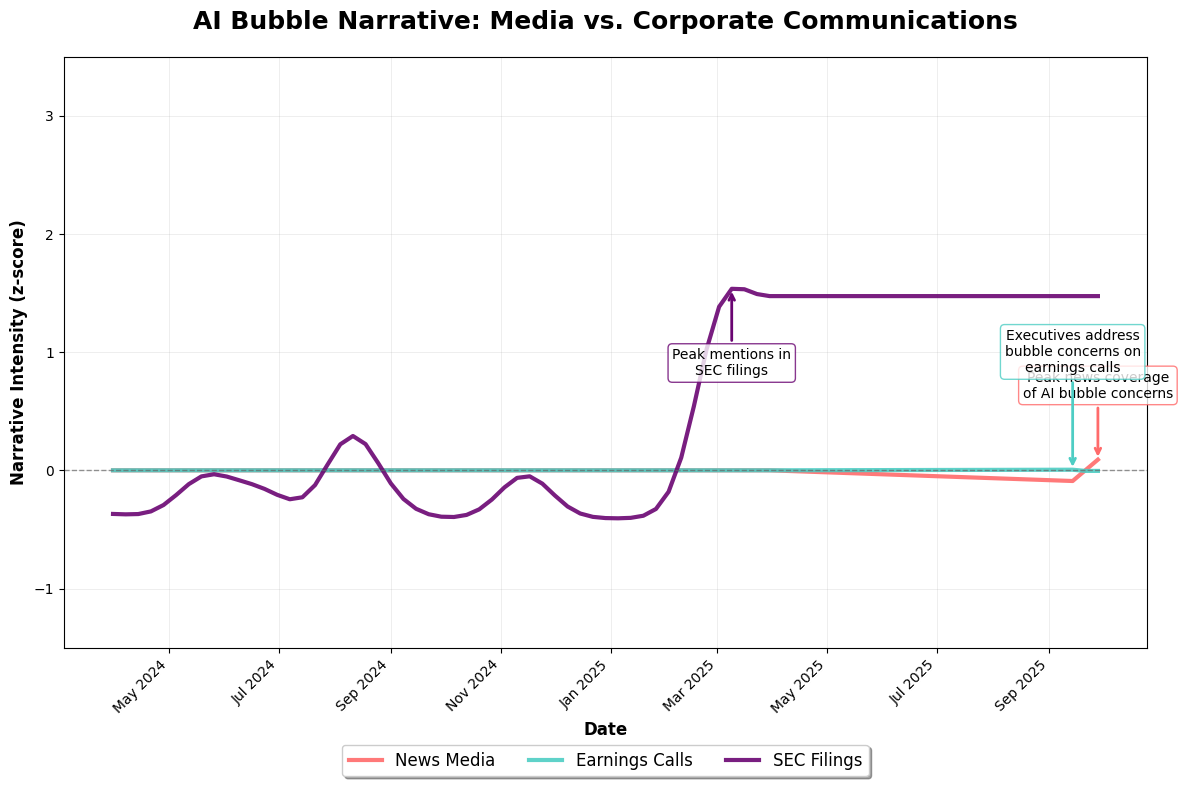

In [ ]:
import warnings
warnings.filterwarnings("ignore", message=".*'method'.*", category=FutureWarning)

fig1 = visualize_cross_source_narratives(news_df, transcripts_df, filings_df, interactive=False) #set interactive=True (or False) to enable (or disable) the interactive plot
fig1.show()  

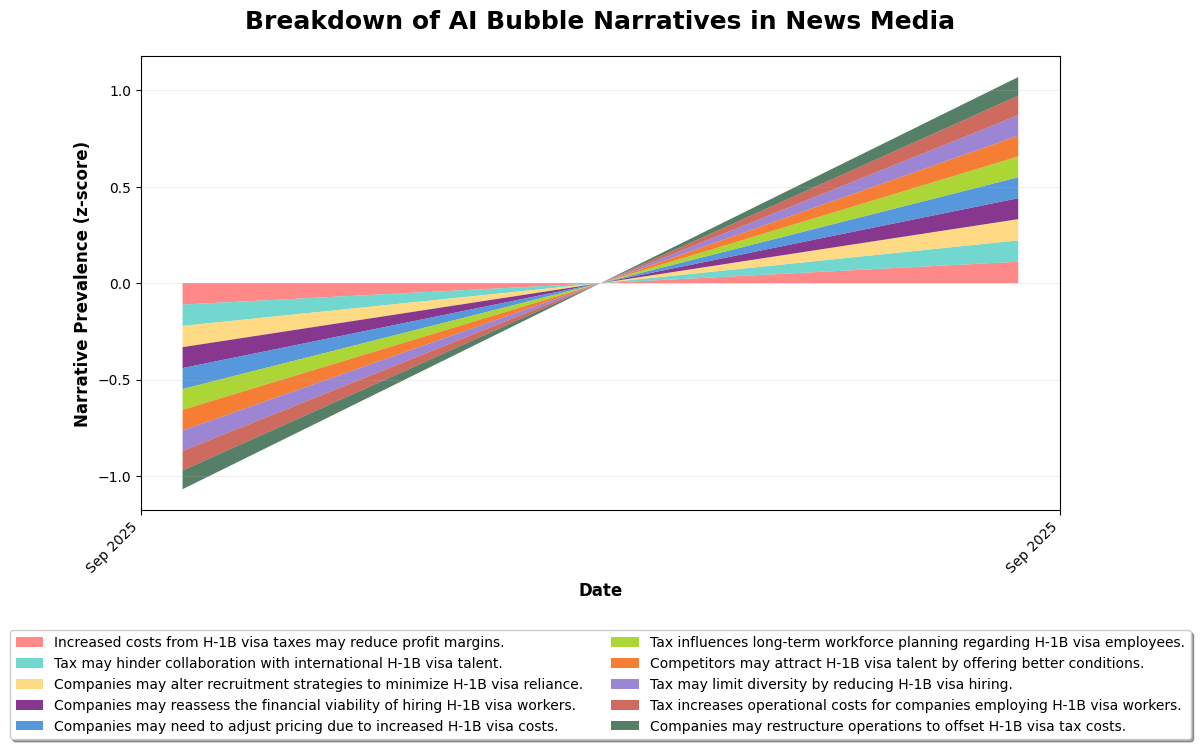

In [ ]:
# Create the narrative breakdown visualization for news 
fig2 = visualize_news_narrative_breakdown(news_df, interactive=False) #set interactive=True (or False) to enable (or disable) the interactive plot
fig2.show()

## Extract and Display Key Insights

Extract key insights from the narrative mining data and display them.

In [ ]:
# Extract insights from our narrative mining data
insights = extract_narrative_insights(news_df, transcripts_df, filings_df)

print("## AI Bubble Narrative Key Insights\n")
print(f"Peak month for news coverage: {insights['peak_news_month']}")
print(f"Peak month for earnings call mentions: {insights['peak_transcript_month']}")
print(f"Peak month for regulatory filing mentions: {insights['peak_filing_month']}")
print(f"\nDominant narrative in news: \"{insights['top_news_narrative']}\"")
print(f"Dominant narrative in earnings calls: \"{insights['top_transcript_narrative']}\"")
print(f"Dominant narrative in regulatory filings: \"{insights['top_filing_narrative']}\"")
print(f"\nTotal narrative mentions in news: {insights['total_news_mentions']}")
print(f"Total mentions in earnings calls: {insights['total_transcript_mentions']}")
print(f"Total mentions in regulatory filings: {insights['total_filing_mentions']}")
print(f"\nAverage lag between news coverage peaks and SEC filings: {insights['avg_lag_days']} days")

## AI Bubble Narrative Key Insights

Peak month for news coverage: September 2025
Peak month for earnings call mentions: September 2025
Peak month for regulatory filing mentions: March 2025

Dominant narrative in news: "A proposed tax impacting companies employing H-1B visa holders."
Dominant narrative in earnings calls: "Companies prefer focusing on long-term strategy"
Dominant narrative in regulatory filings: "Current AI investments may not generate predicted financial returns"

Total narrative mentions in news: 56503
Total mentions in earnings calls: 784
Total mentions in regulatory filings: 2645

Average lag between news coverage peaks and SEC filings: -182 days


## Export the Results

Export the data as Excel files for further analysis or to share with the team.

In [ ]:
try:
    # Create the Excel manager
    excel_manager = ExcelManager()

    # Define the dataframes and their sheet configurations
    df_args = [
        (news_df, "News Narratives", (0, 0)),
        (transcripts_df, "Earnings Call Narratives", (0, 0)),
        (filings_df, "SEC Filing Narratives", (0, 0)),
        (source_summary, "Summary", (1, 1))
    ]

    # Save the workbook
    combined_results_path = f"{output_dir}/ai_bubble_narrative_analysis.xlsx"
    excel_manager.save_workbook(df_args, combined_results_path)
    
    print(f"✅ Results exported to {combined_results_path}")

except Exception as e:
    print(f"Warning while exporting to excel: {e}")

✅ Results exported to output/ai_bubble_narrative_analysis.xlsx


## Conclusion

The Narrative Miners reveal important patterns in how the AI bubble narrative evolved across information sources:

**Timing and Intensity Variations:**

- News media shows major spikes in AI bubble concerns, often leading the narrative cycle with the highest peaks
- Earnings calls demonstrate cyclical attention to bubble concerns, with executives addressing topics most prominently during specific quarters
- SEC filings show the most volatile pattern with multiple significant spikes, suggesting ongoing regulatory concerns

**Narrative Progression:**

- Media coverage often leads the initial bubble narrative, potentially triggering corporate responses visible in earnings calls
- Corporate executives' discussions peak during specific periods but tend to diminish over time
- SEC filing mentions frequently show increased intensity throughout the analysis period, indicating persistent regulatory attention

**Cross-Source Intelligence:**

- Different sources provide complementary perspectives on the same underlying narrative
- Timing lags between sources reveal information flow patterns and decision-making hierarchies
- The intensity patterns help identify when narratives are gaining or losing momentum across different stakeholder groups

This analysis demonstrates how systematic narrative mining across multiple document types provides richer insights than analyzing any single source in isolation.